# Authors
- Raphael Wäspi (18-918-938)
- Nicolas Huber (16-936-205)

In [316]:
import math
# Imports
import copy
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import os
import glob
import re
import random
from matplotlib.ticker import FuncFormatter
from statistics import mean

import scipy.special
from tqdm import tqdm
import shutil
from joblib import Parallel, delayed
from scipy.special import factorial
import powerlaw
from NEMtropy import UndirectedGraph
from matplotlib.colors import LinearSegmentedColormap


In [317]:
# Define colors with reduced opacity from a colormap
COLOR_BLUE = 'dodgerblue'
COLOR_RED = 'lightcoral'
COLOR_GREY = 'slategrey'
COLOR_BLACK = 'black'
COLOR_LIGHT_GRAY = 'lightgray'
COLOR_DARK_GRAY = 'darkgray'

# Define the main data directory
OUTPUT_PATH = "./output"

In [318]:
# Prepare output folder

# Delete the entire 'output' directory and its contents
if os.path.exists(OUTPUT_PATH):
    shutil.rmtree(OUTPUT_PATH)

# Create the 'output' directory
os.makedirs(OUTPUT_PATH)

# Define subdirectories
OUTPUT_PATH_ER = os.path.join(OUTPUT_PATH, "erdos_renyi_avg_clustering")
OUTPUT_PATH_SYNTHETIC = os.path.join(OUTPUT_PATH, "synthetic")
OUTPUT_PATH_NODE_REMOVALS = os.path.join(OUTPUT_PATH, "node_removals")



# Recreate the subdirectories
os.makedirs(OUTPUT_PATH_ER)
os.makedirs(OUTPUT_PATH_SYNTHETIC)
os.makedirs(OUTPUT_PATH_NODE_REMOVALS)

In [319]:
# Define the directory containing the .gml files
directory = 'assignment_03_data'

# Use glob to get a list of all .gml files in the directory
gml_files = glob.glob(os.path.join(directory, '*.gml'))

# Init an empty dictionary for all graphs - the key is the actual name, and the value is the graph data
graphs = {}

# Use tqdm to show a progress bar in Jupyter Notebook
with tqdm(total=len(gml_files), desc="Loading GML Files") as pbar:
    # Loop through the list of .gml files and load them
    for file_path in gml_files:
        with open(file_path, 'r') as file:
            content = file.read()
            
            # Use regex to extract the desired part
            match = re.search(r'/([^/]+)\.gml$', file_path)
            if match:
                graph_name = match.group(1)
                
                # Add to the graph dictionary
                graph = nx.read_gml(file_path)
                graphs[graph_name] = graph
                
                # Print the graph name when each part is finished
                print(f"Finished loading {graph_name}")
                
        pbar.update(1)  # Update the progress bar

Loading GML Files:  50%|█████     | 1/2 [00:00<00:00,  6.35it/s]

Finished loading graph_eu_airlines


Loading GML Files: 100%|██████████| 2/2 [00:00<00:00,  2.99it/s]

Finished loading graph_power


In [320]:
# Define the directory containing the .gml files
directory = 'assignment_03_data/World_Trade_Web'

# Use glob to get a list of all .gml files in the directory
gml_files = glob.glob(os.path.join(directory, '*.graphml'))

# Init an empty dictionary for all graphs - the key is the actual name, and the value is the graph data
graphs_wtn = {}

# Use tqdm to show a progress bar in Jupyter Notebook
with tqdm(total=len(gml_files), desc="Loading GML WTW Files") as pbar:
    # Loop through the list of .gml files and load them
    for file_path in gml_files:
        with open(file_path, 'r') as file:
            content = file.read()

            # Use regex to extract the desired part
            match = re.search(r'/([^/]+)\.txt.graphml$', file_path)
            if match:
                graph_name = match.group(1)

                # Add to the graph dictionary
                graph = nx.read_graphml(file_path)
                graphs_wtn[graph_name] = graph

                # Print the graph name when each part is finished
                print(f"Finished loading {graph_name}")

        pbar.update(1)  # Update the progress bar

Loading GML WTW Files:   9%|▉         | 1/11 [00:00<00:01,  5.05it/s]

Finished loading WDN_1997
Finished loading WDN_1992


Loading GML WTW Files:  36%|███▋      | 4/11 [00:00<00:01,  6.39it/s]

Finished loading WDN_2000
Finished loading WDN_1998


Loading GML WTW Files:  45%|████▌     | 5/11 [00:00<00:00,  6.96it/s]

...

Finished loading WDN_2002
Finished loading WDN_1996


Loading GML WTW Files:  91%|█████████ | 10/11 [00:04<00:00,  2.35it/s]

Finished loading WDN_1995
Finished loading WDN_1999


Loading GML WTW Files: 100%|██████████| 11/11 [00:04<00:00,  2.42it/s]

Finished loading WDN_2001


# III Robustness

## 1. Generate synthetic networks (you can use whatever module you prefer):
1. Random networks (ErdosRényi) (with $n = 1000$ and $\langle k \rangle = \{1,4\}$)
2. Scale-free networks (Barabási-Albert) (with $n = 1000$ and $m = \{2,4\}$)

In [321]:
N = 1000
K_VALUES = [1, 4] # range(1, 5, 1)
M_VALUES = [2, 4] # range(2, 5, 1)
CONSIDERED_GRAPHS = ['graph_eu_airlines', 'graph_power']

In [322]:
er_graphs = {}
ba_graphs = {}

In [323]:
def generate_ER_graphs(nodes, k_values, number):
    graphs = {}
    
    # Generate n graphs for each k value
    for avg_degree in k_values:
        graphs[avg_degree] = {}
    
        for index in range(1, number+1, 1):
            
            probability = avg_degree / (nodes - 1)
            
            graph = nx.erdos_renyi_graph(n=nodes, p=probability)
            
            graphs[avg_degree][index] = graph
            
    return graphs

In [324]:
er_graphs = generate_ER_graphs(nodes=N, k_values=K_VALUES, number=1)
er_graphs

{1: {1: <networkx.classes.graph.Graph at 0x11f733fd0>},
 4: {1: <networkx.classes.graph.Graph at 0x155c32210>}}

In [325]:
def generate_BA_graphs(nodes, m_values, number):
    graphs = {}

    # Generate n graphs for each m value
    for m in m_values:
        graphs[m] = {}

        for index in range(1, number+1, 1):

            graph = nx.barabasi_albert_graph(n=nodes, m=m)

            graphs[m][index] = graph

    return graphs

In [326]:
ba_graphs = generate_BA_graphs(nodes=N, m_values=M_VALUES, number=1)
ba_graphs

{2: {1: <networkx.classes.graph.Graph at 0x11fad7ed0>},
 4: {1: <networkx.classes.graph.Graph at 0x1201531d0>}}

## 2. Plot the degree distributions of the synthetic networks and of the networks provided in the datasets.

In [327]:
def plot_degree_distribution(ax, graph, color, param, graph_index, er):
    degrees = [degree for node, degree in graph.degree()]
    degree_freq = nx.degree_histogram(graph)
    ax.bar(range(len(degree_freq)), degree_freq, width=0.8, color=color)
    ax.set_xlabel('Degree')
    ax.set_ylabel('Frequency')
    if er:
        ax.set_title(fr"Degree Distribution of graph iteration {graph_index} with $\langle k \rangle = {param}$")
    else:
        ax.set_title(fr"Degree Distribution of graph iteration {graph_index} with $m = {param}$")
    

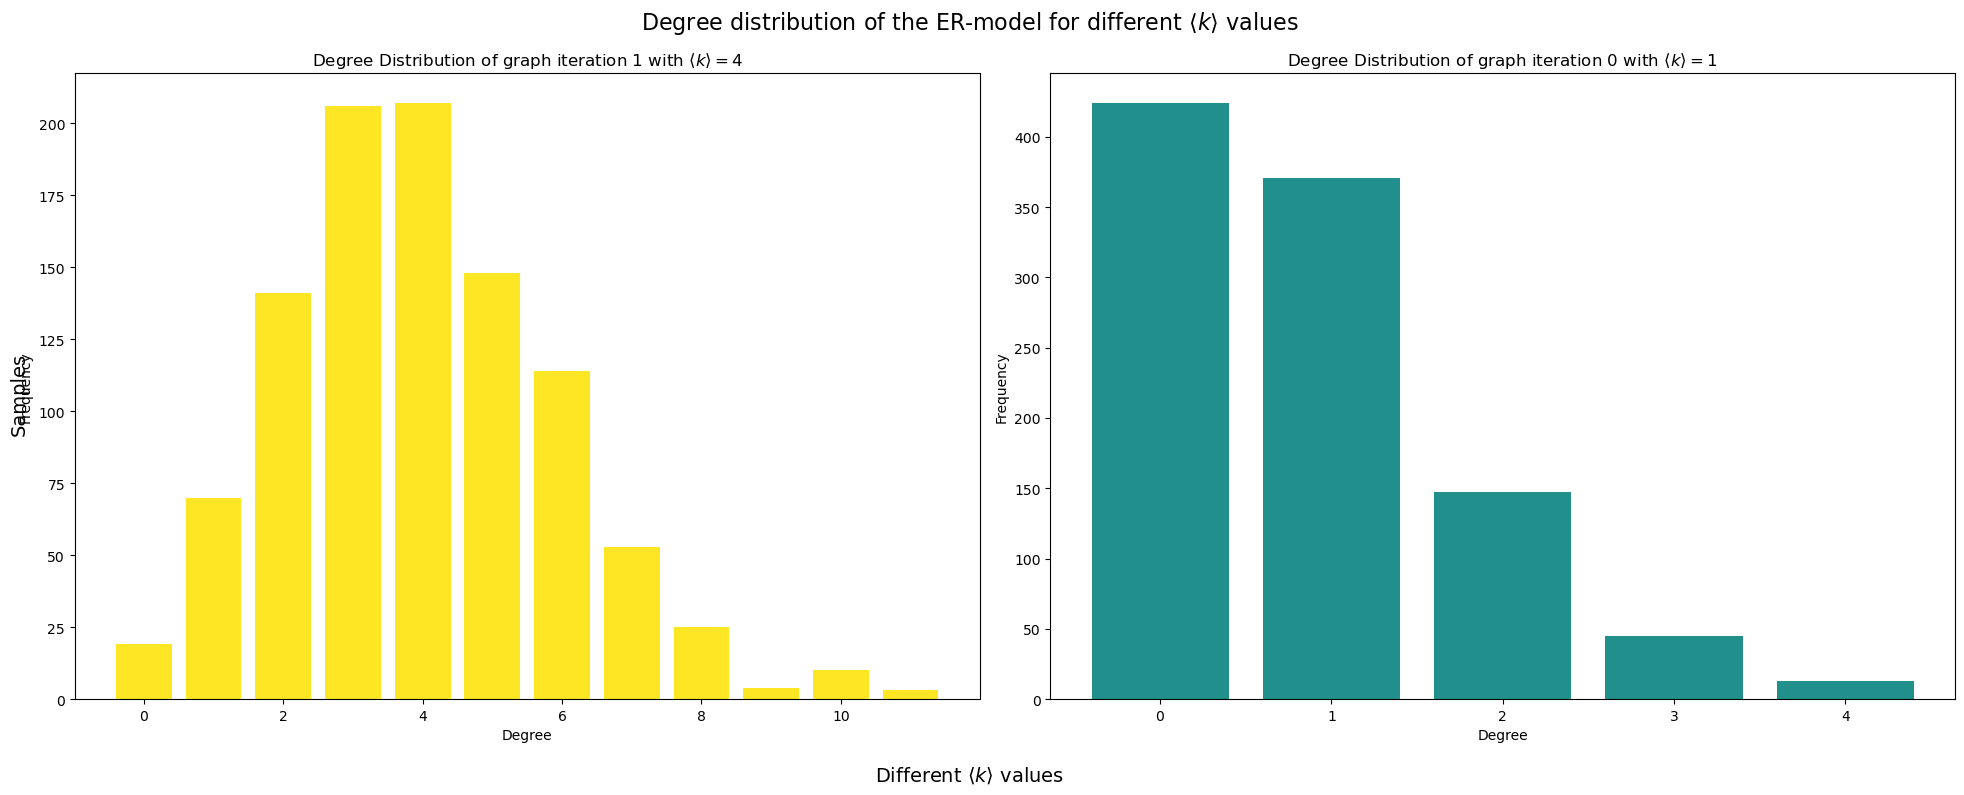

In [328]:
# ER-graphs
# Define colors for different average degrees using a colormap
num_avg_degrees = len(er_graphs)
colors = plt.cm.viridis_r([i / num_avg_degrees for i in range(num_avg_degrees)])

# Create a subplot grid
num_instances = len(next(iter(er_graphs.values())))  # Assuming all instances have the same count
fig, axs = plt.subplots(num_instances, num_avg_degrees, figsize=(20, 8))

# Iterate through avg_degree_index and graph_index
for avg_degree_index, (avg_degree, avg_degree_plots) in enumerate(er_graphs.items()):
    color = colors[avg_degree_index - 1]  # Get color for the degree
    for graph_index, graph in avg_degree_plots.items():
        # Get the appropriate axis for the subplot
        if num_instances == 1:
            ax = axs[avg_degree_index - 1]
        else:
            ax = axs[graph_index - 1, avg_degree_index - 1]

        # Plot on the corresponding axis with the assigned color
        plot_degree_distribution(ax=ax, graph=graph, color=color, param=avg_degree, graph_index=avg_degree_index, er=True)


fig.suptitle(fr"Degree distribution of the ER-model for different $\langle k \rangle$ values", fontsize=16)
fig.supxlabel(fr"Different $\langle k \rangle$ values", fontsize=14)
fig.supylabel("Samples", fontsize=14)


# Adjust layout and display the plot
plt.tight_layout()
file_name=f"degree_dist_er_synth_networks.png"
complete_plot_filename=os.path.join(OUTPUT_PATH_SYNTHETIC, file_name)
plt.savefig(complete_plot_filename)
plt.show()

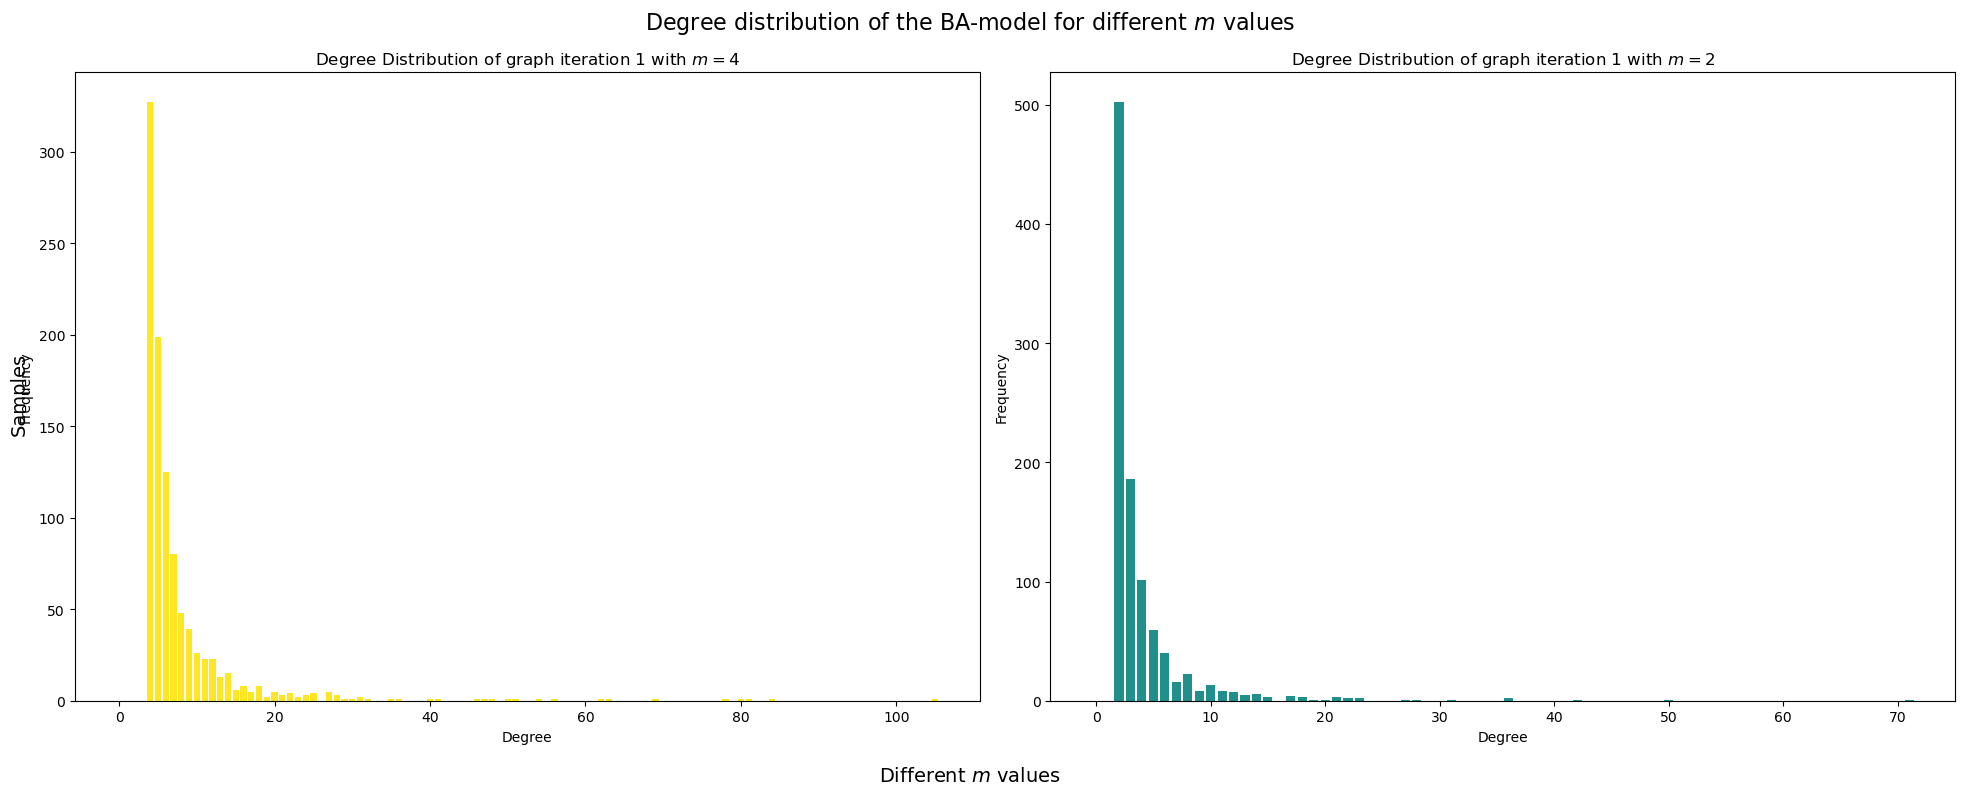

In [329]:
# BA-graphs
# Define colors for different average degrees using a colormap
num_ba_values = len(ba_graphs)
colors = plt.cm.viridis_r([i / num_ba_values for i in range(num_ba_values)])
# Create a subplot grid
num_instances = len(next(iter(ba_graphs.values())))  # Assuming all instances have the same count
fig, axs = plt.subplots(num_instances, num_ba_values, figsize=(20, 8))

# Iterate through avg_degree_index and graph_index
for m_index, (m, m_plots) in enumerate(ba_graphs.items()): # Do not forget that m is not an index -> use enumerate and m_index
    color = colors[m_index - 1]  # Get color for the degree
    for graph_index, graph in m_plots.items():
        # Get the appropriate axis for the subplot
        if num_instances == 1:
            ax = axs[m_index - 1]
        else:
            ax = axs[graph_index - 1, m_index - 1]

        # Plot on the corresponding axis with the assigned color
        plot_degree_distribution(ax=ax, graph=graph, color=color, param=m, graph_index=graph_index, er=False)

fig.suptitle(fr"Degree distribution of the BA-model for different $m$ values", fontsize=16)
fig.supxlabel(fr"Different $m$ values", fontsize=14)
fig.supylabel("Samples", fontsize=14)


# Adjust layout and display the plot
plt.tight_layout()
file_name=f"degree_dist_ba_synth_networks.png"
complete_plot_filename=os.path.join(OUTPUT_PATH_SYNTHETIC, file_name)
plt.savefig(complete_plot_filename)
plt.show()

## 3. Plot the size of the largest connected component as a function of removed edges and nodes in two scenarios for the synthetic graphs and the real networks in the datasets:
(a) Random attacks (failures)
(b) Targeted attacks (degree centrality and betweenness centrality)

In [330]:
K_ESTIMATOR = 100

In [331]:
def remove_random_nodes(graph, n):
    # Copy it such that we do not need to import it again
    updated_graph = copy.deepcopy(graph)
    nodes_list = list(updated_graph.nodes())

    if len(nodes_list) < n:
        return graph, []

    extracted_nodes = []
    for _ in range(n):
        if nodes_list:
            random_node = random.choice(nodes_list)
            updated_graph.remove_node(random_node)
            extracted_nodes.append(random_node)
            nodes_list.remove(random_node)
        else:
            break
    
    # DEBUG
    # print(f"Removed nodes: {extracted_nodes}")
    return updated_graph, extracted_nodes

In [332]:
def remove_random_percentage_nodes(graph, percentage):
    if not 0 <= percentage <= 100:
        raise ValueError("Percentage should be between 0 and 100")

    num_nodes = len(graph.nodes())
    num_to_remove = int(num_nodes * (percentage / 100))

    return remove_random_nodes(graph, num_to_remove)

In [333]:
PERCENTAGES_TO_BE_REMOVED = range(1, 100, 1)
#PERCENTAGES_TO_BE_REMOVED = [1,50]

In [334]:
TOP_N_TO_BE_REMOVED = [0,1,2,3,4,5,10]
#TOP_N_TO_BE_REMOVED = [1,2]

In [335]:
random_removed_graphs = {}

In [336]:
def generate_random_removed_graphs(graphs, percentages_to_be_removed, top_n_to_be_removed):
    random_removed_graphs = {}

    def process_graph(graph, graph_name, action, value):
        nonlocal random_removed_graphs
        if graph_name not in random_removed_graphs:
            random_removed_graphs[graph_name] = {}

        random_removed_graphs[graph_name][action] = {}
        updated_graph, extracted_nodes = value
        random_removed_graphs[graph_name][action]["graph"] = updated_graph
        removed_nodes = graph.number_of_nodes() - updated_graph.number_of_nodes()
        random_removed_graphs[graph_name][action]["reduced_nodes"] = removed_nodes
        #print(f"{action} of graph {graph_name}")
        #print(f"Graph {graph_name} has {graph.number_of_nodes()}")
        #print(f"Graph (updated) {graph_name} has {updated_graph.number_of_nodes()}")
        #print(f"Removed Nodes: {removed_nodes}")
        #print("---")

    for graph_name, graph in graphs.items():
        for percentage in percentages_to_be_removed:
            action = str(percentage) + '%'
            process_graph(graph, graph_name, action, remove_random_percentage_nodes(graph=graph, percentage=percentage))

        for top_n in top_n_to_be_removed:
            action = f"{top_n}"
            process_graph(graph, graph_name, action, remove_random_nodes(graph=graph, n=top_n))

    return random_removed_graphs

In [337]:
random_removed_graphs = generate_random_removed_graphs(graphs=graphs, percentages_to_be_removed=PERCENTAGES_TO_BE_REMOVED, top_n_to_be_removed=TOP_N_TO_BE_REMOVED)

In [338]:
def sort_nodes_by_degree_centrality(graph):
    degree_centrality = nx.degree_centrality(graph)
    sorted_by_degree = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)
    return sorted_by_degree

In [339]:
def sort_nodes_by_betweenness_centrality(graph):
    betweenness_centrality = nx.betweenness_centrality(graph)
    sorted_by_betweenness = sorted(betweenness_centrality.items(), key=lambda x: x[1], reverse=True)
    return sorted_by_betweenness

In [340]:
def remove_targeted_nodes(graph, centrality_measure, n):
    if centrality_measure == 'degree':
        sorted_nodes = sorted(nx.degree_centrality(graph).items(), key=lambda x: x[1], reverse=True)
    elif centrality_measure == 'betweenness':
        sorted_nodes = sorted(nx.betweenness_centrality(graph, k=K_ESTIMATOR).items(), key=lambda x: x[1], reverse=True)
    else:
        raise ValueError("Centrality measure should be 'degree' or 'betweenness'")

    updated_graph = copy.deepcopy(graph)

    if len(sorted_nodes) < n:
        return graph, []

    extracted_nodes = []
    for i in range(n):
        node = sorted_nodes[i][0]  # Extracting node from the sorted list
        updated_graph.remove_node(node)
        extracted_nodes.append(node)

    # DEBUG
    # print(f"Removed nodes: {extracted_nodes}")
    return updated_graph, extracted_nodes

In [341]:
def remove_target_percentage_nodes(graph, centrality_measure, percentage):
    if not 0 <= percentage <= 100:
        raise ValueError("Percentage should be between 0 and 100")

    num_nodes = len(graph.nodes())
    num_to_remove = int(num_nodes * (percentage / 100))

    return remove_targeted_nodes(graph, centrality_measure, num_to_remove)

In [342]:
target_degree_centrality_removed_graphs = {}

In [343]:
def generate_target_degree_centrality_removed_graphs(graphs, percentages_to_be_removed, top_n_to_be_removed):
    target_degree_centrality_removed_graphs = {}

    def process_graph(graph, graph_name, action, value):
        nonlocal target_degree_centrality_removed_graphs
        if graph_name not in target_degree_centrality_removed_graphs:
            target_degree_centrality_removed_graphs[graph_name] = {}

        target_degree_centrality_removed_graphs[graph_name][action] = {}
        updated_graph, extracted_nodes = value
        target_degree_centrality_removed_graphs[graph_name][action]["graph"] = updated_graph
        removed_nodes = graph.number_of_nodes() - updated_graph.number_of_nodes()
        target_degree_centrality_removed_graphs[graph_name][action]["reduced_nodes"] = removed_nodes
        #print(f"{action} of graph {graph_name}")
        #print(f"Graph {graph_name} has {graph.number_of_nodes()}")
        #print(f"Graph (updated) {graph_name} has {updated_graph.number_of_nodes()}")
        #print(f"Removed Nodes: {removed_nodes}")
        #print("---")

    for graph_name, graph in graphs.items():
        for percentage in percentages_to_be_removed:
            action = str(percentage) + '%'
            process_graph(graph, graph_name, action, remove_target_percentage_nodes(graph=graph, centrality_measure='degree', percentage=percentage))

        for top_n in top_n_to_be_removed:
            action = f"{top_n}"
            process_graph(graph, graph_name, action, remove_targeted_nodes(graph=graph, centrality_measure='degree', n=top_n))

    return target_degree_centrality_removed_graphs

In [344]:
target_degree_centrality_removed_graphs = generate_target_degree_centrality_removed_graphs(graphs=graphs, percentages_to_be_removed=PERCENTAGES_TO_BE_REMOVED, top_n_to_be_removed=TOP_N_TO_BE_REMOVED)

In [345]:
target_betweenness_centrality_removed_graphs = {}

In [346]:
def generate_target_betweenness_centrality_removed_graphs(graphs, percentages_to_be_removed, top_n_to_be_removed):
    target_betweenness_centrality_removed_graphs = {}

    def process_graph(graph, graph_name, action, value):
        nonlocal target_betweenness_centrality_removed_graphs
        if graph_name not in target_betweenness_centrality_removed_graphs:
            target_betweenness_centrality_removed_graphs[graph_name] = {}

        target_betweenness_centrality_removed_graphs[graph_name][action] = {}
        updated_graph, extracted_nodes = value
        target_betweenness_centrality_removed_graphs[graph_name][action]["graph"] = updated_graph
        removed_nodes = graph.number_of_nodes() - updated_graph.number_of_nodes()
        target_betweenness_centrality_removed_graphs[graph_name][action]["reduced_nodes"] = removed_nodes
        #print(f"{action} of graph {graph_name}")
        #print(f"Graph {graph_name} has {graph.number_of_nodes()}")
        #print(f"Graph (updated) {graph_name} has {updated_graph.number_of_nodes()}")
        #print(f"Removed Nodes: {removed_nodes}")
        #print("---")

    for graph_name, graph in graphs.items():
        for percentage in percentages_to_be_removed:
            action = str(percentage) + '%'
            process_graph(graph, graph_name, action, remove_target_percentage_nodes(graph=graph, centrality_measure='betweenness', percentage=percentage))

        for top_n in top_n_to_be_removed:
            action = f"{top_n}"
            process_graph(graph, graph_name, action, remove_targeted_nodes(graph=graph, centrality_measure='betweenness', n=top_n))

    return target_betweenness_centrality_removed_graphs


In [347]:
target_betweenness_centrality_removed_graphs = generate_target_betweenness_centrality_removed_graphs(graphs=graphs, percentages_to_be_removed=PERCENTAGES_TO_BE_REMOVED, top_n_to_be_removed=TOP_N_TO_BE_REMOVED)

In [348]:
#random_removed_graphs

In [349]:
plot_data_random = {}

In [350]:
def generate_plot_data(graphs):
    plot_data = {}

    for graph_name, cases in graphs.items():
        #print(f"Graph: {graph_name}")
        plot_data[graph_name] = {
            'percentage': {'x_percentages_removed': [], 'y_size_lcc': [], 'y_size_lcc_frac': []},
            'absolute': {'x_absolute_removed': [], 'y_size_lcc': [], 'y_size_lcc_frac': []}
        }

        for case, data in cases.items():
            graph = data['graph']
            largest_cc = max(nx.connected_components(graph), key=len)
            largest_connected_component = graph.subgraph(largest_cc)
            size_largest_cc = len(largest_connected_component)

            #print(f"Case: {case}")
            #print(f"Size of largest connected component: {size_largest_cc}")
            if '%' in str(case):
                plot_data[graph_name]['percentage']['x_percentages_removed'].append(int(str(case).replace('%', ''))/100)
                plot_data[graph_name]['percentage']['y_size_lcc'].append(size_largest_cc)
                plot_data[graph_name]['percentage']['y_size_lcc_frac'].append(size_largest_cc/plot_data[graph_name]['percentage']['y_size_lcc'][0])
            else:
                plot_data[graph_name]['absolute']['x_absolute_removed'].append(case)
                plot_data[graph_name]['absolute']['y_size_lcc'].append(size_largest_cc)
                plot_data[graph_name]['absolute']['y_size_lcc_frac'].append(size_largest_cc/plot_data[graph_name]['absolute']['y_size_lcc'][0])

            #print()

    return plot_data


In [351]:
plot_data_random = generate_plot_data(random_removed_graphs)

In [352]:
#plot_data_random

In [353]:
def percent_formatter(x, pos):
    return '{:.0%}'.format(x)

In [354]:
def lowercase_and_replace_spaces(input_string):
    # Convert the string to lowercase
    lowercase_string = input_string.lower()
    # Replace spaces with underscores
    modified_string = lowercase_string.replace(' ', '_')
    modified_string = modified_string.replace(':', '')
    return modified_string
def plot_removed_data(plot_data, title):
    fig, axs = plt.subplots(2, 2, figsize=(18, 18))
    for graph_name, data in plot_data.items():
        # x: percentage of removed nodes, y: absolute size of lcc after removal
        axs[0, 0].plot(data['percentage']['x_percentages_removed'],
                          data['percentage']['y_size_lcc'],
                          label=graph_name, marker='o')

        # x: absolute removed nodes, y: absolute size of lcc after removal
        axs[0, 1].plot(data['absolute']['x_absolute_removed'],
                          data['absolute']['y_size_lcc'],
                          label=graph_name, marker='o')

        # x: percentage of removed nodes, y: percentage of lcc after removal (lcc / lcc_before_removal)
        axs[1, 0].plot(data['percentage']['x_percentages_removed'],
                          data['percentage']['y_size_lcc_frac'],
                          label=graph_name, marker='o')

        # x: absolute removed nodes, y: percentage of lcc after removal (lcc / lcc_before_removal)
        axs[1, 1].plot(data['absolute']['x_absolute_removed'],
                          data['absolute']['y_size_lcc_frac'],
                          label=graph_name, marker='o')

    # Set x-axis and y-axis labels for each subplot
    axs[0, 0].set_xlabel('% removed nodes')
    axs[0, 0].set_ylabel('# nodes of lcc')

    axs[0, 1].set_xlabel('# removed nodes')
    axs[0, 1].set_ylabel('# nodes of lcc')

    axs[1, 0].set_xlabel('% removed nodes')
    axs[1, 0].set_ylabel('relative size lcc after removal (%)')

    axs[1, 1].set_xlabel('# removed nodes')
    axs[1, 1].set_ylabel('relative size lcc after removal (%)')

    plt.suptitle(title, fontsize=16)

    axs[0, 0].xaxis.set_major_formatter(FuncFormatter(percent_formatter))
    axs[1, 0].xaxis.set_major_formatter(FuncFormatter(percent_formatter))
    axs[0, 0].set_title('Absolute')
    axs[0, 1].set_title('Absolute')
    axs[1, 0].set_title('Percentage')
    axs[1, 1].set_title('Percentage')

    # Get handles and labels for all scatter plots
    handles, labels = axs[0, 0].get_legend_handles_labels()

    # Create a legend for all scatter plots using handles and labels collected above
    plt.legend(handles, labels, loc='upper left', bbox_to_anchor=(-0.25, -0.25))
    plt.tight_layout()
    title_lc = lowercase_and_replace_spaces(title)
    file_name=f"{title_lc}.png"
    complete_plot_filename=os.path.join(OUTPUT_PATH_NODE_REMOVALS, file_name)
    plt.savefig(complete_plot_filename)
    plt.show()

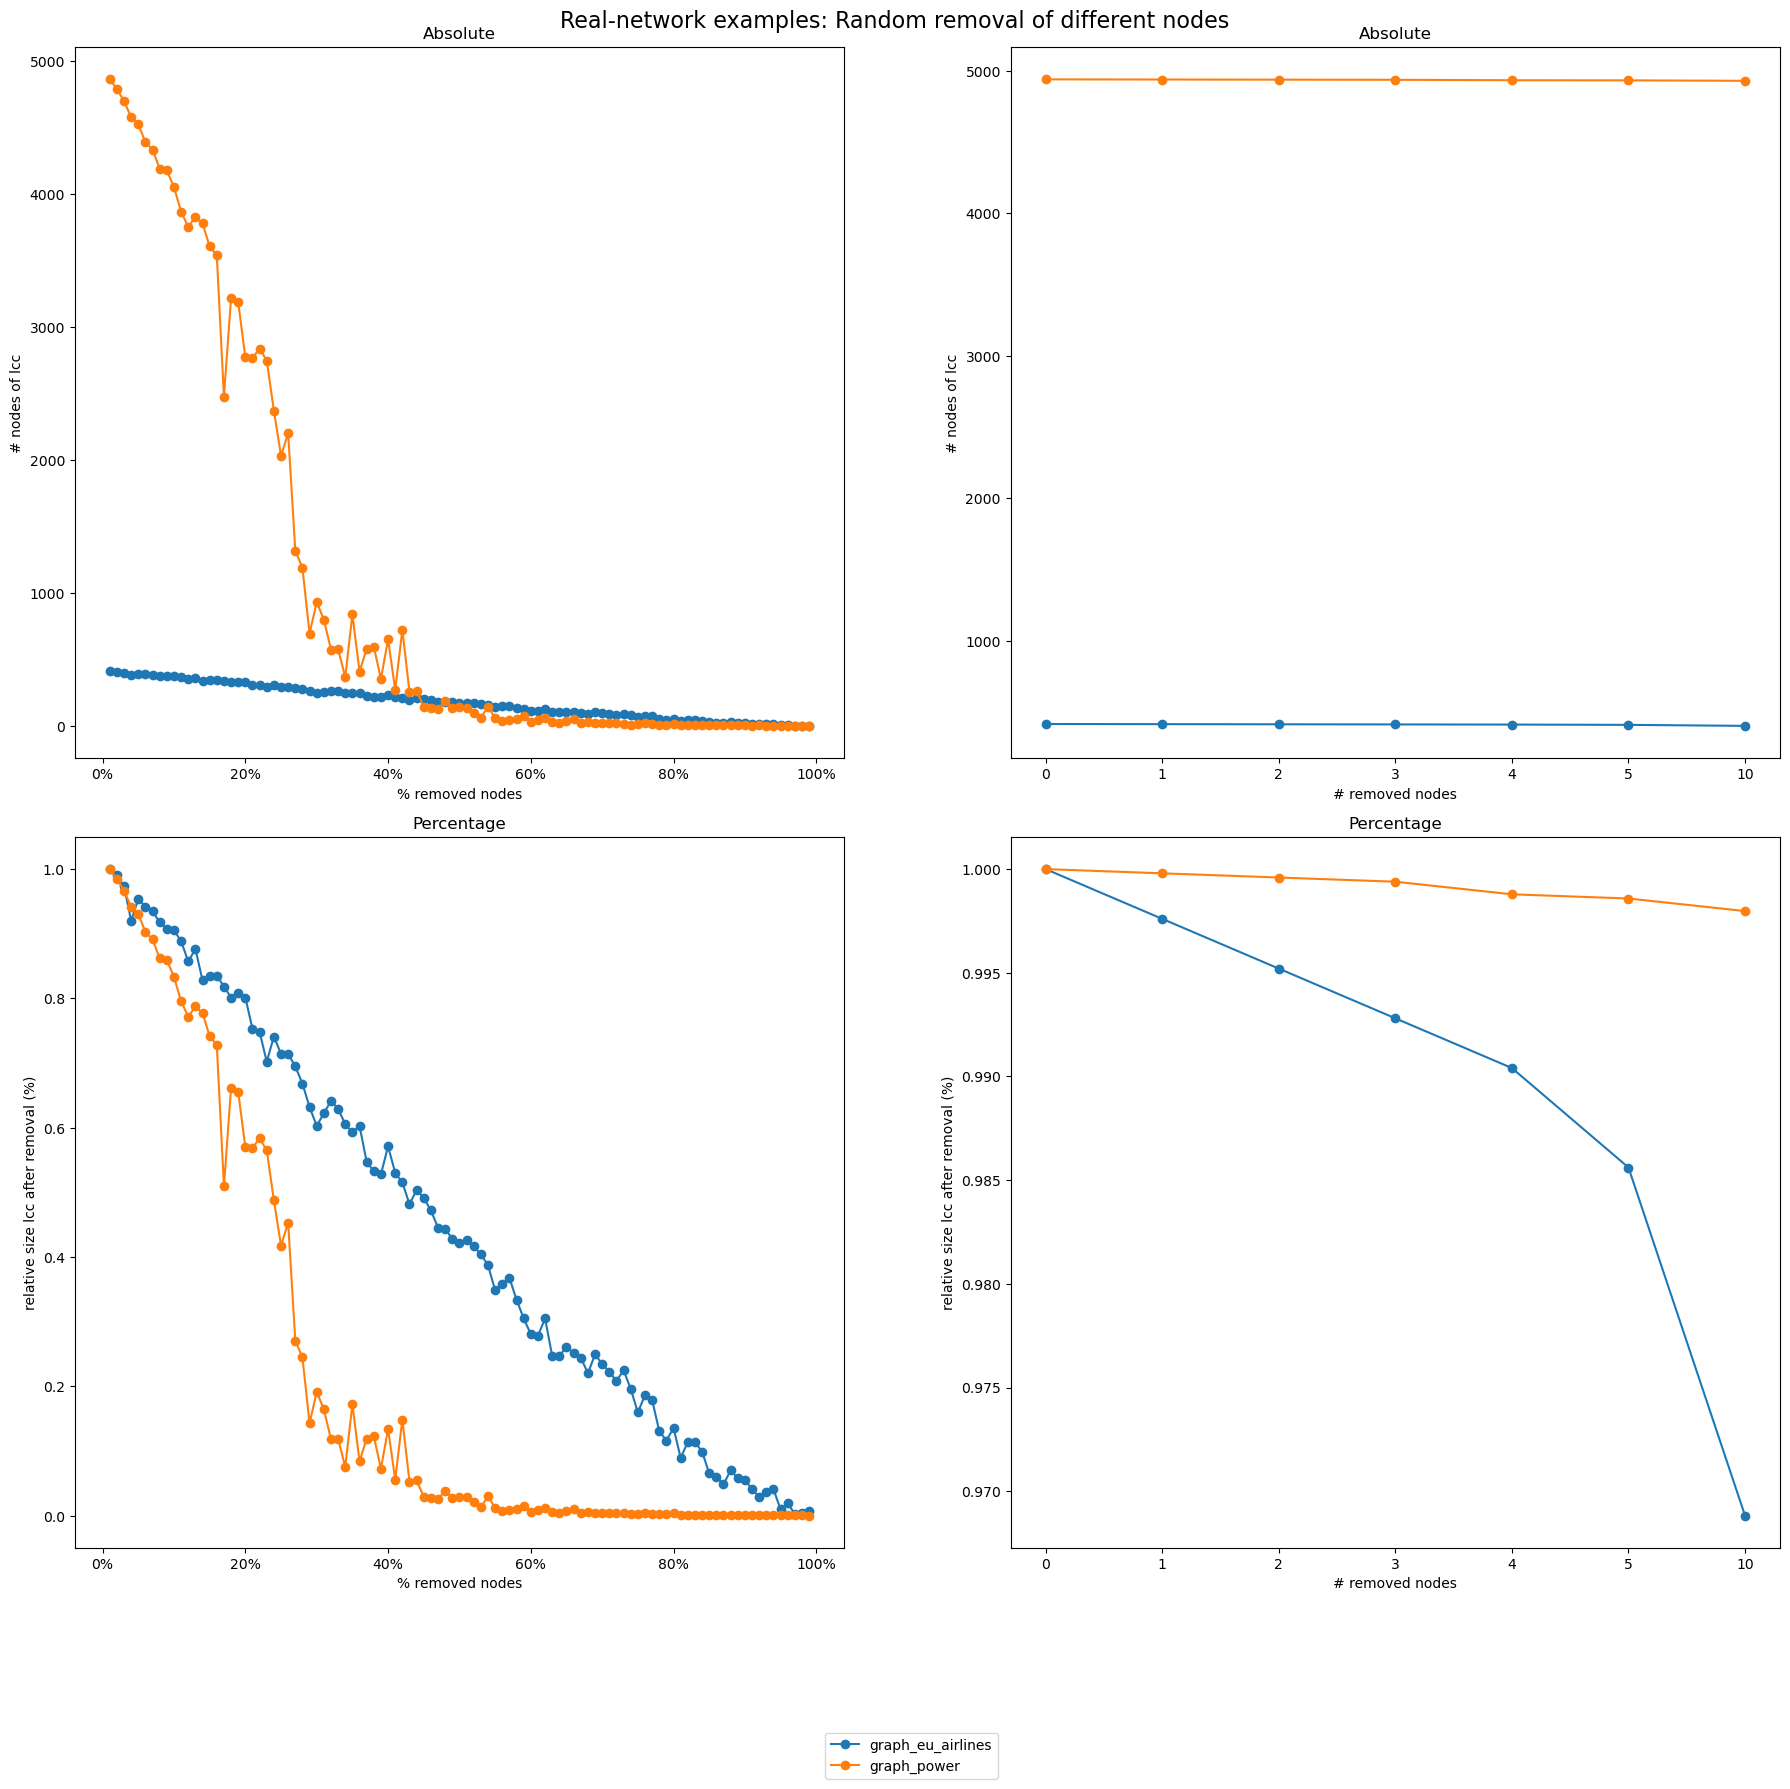

In [355]:
plot_removed_data(plot_data_random, 'Real-network examples: Random removal of different nodes')

In [356]:
plot_data_betweenness = generate_plot_data(target_betweenness_centrality_removed_graphs)

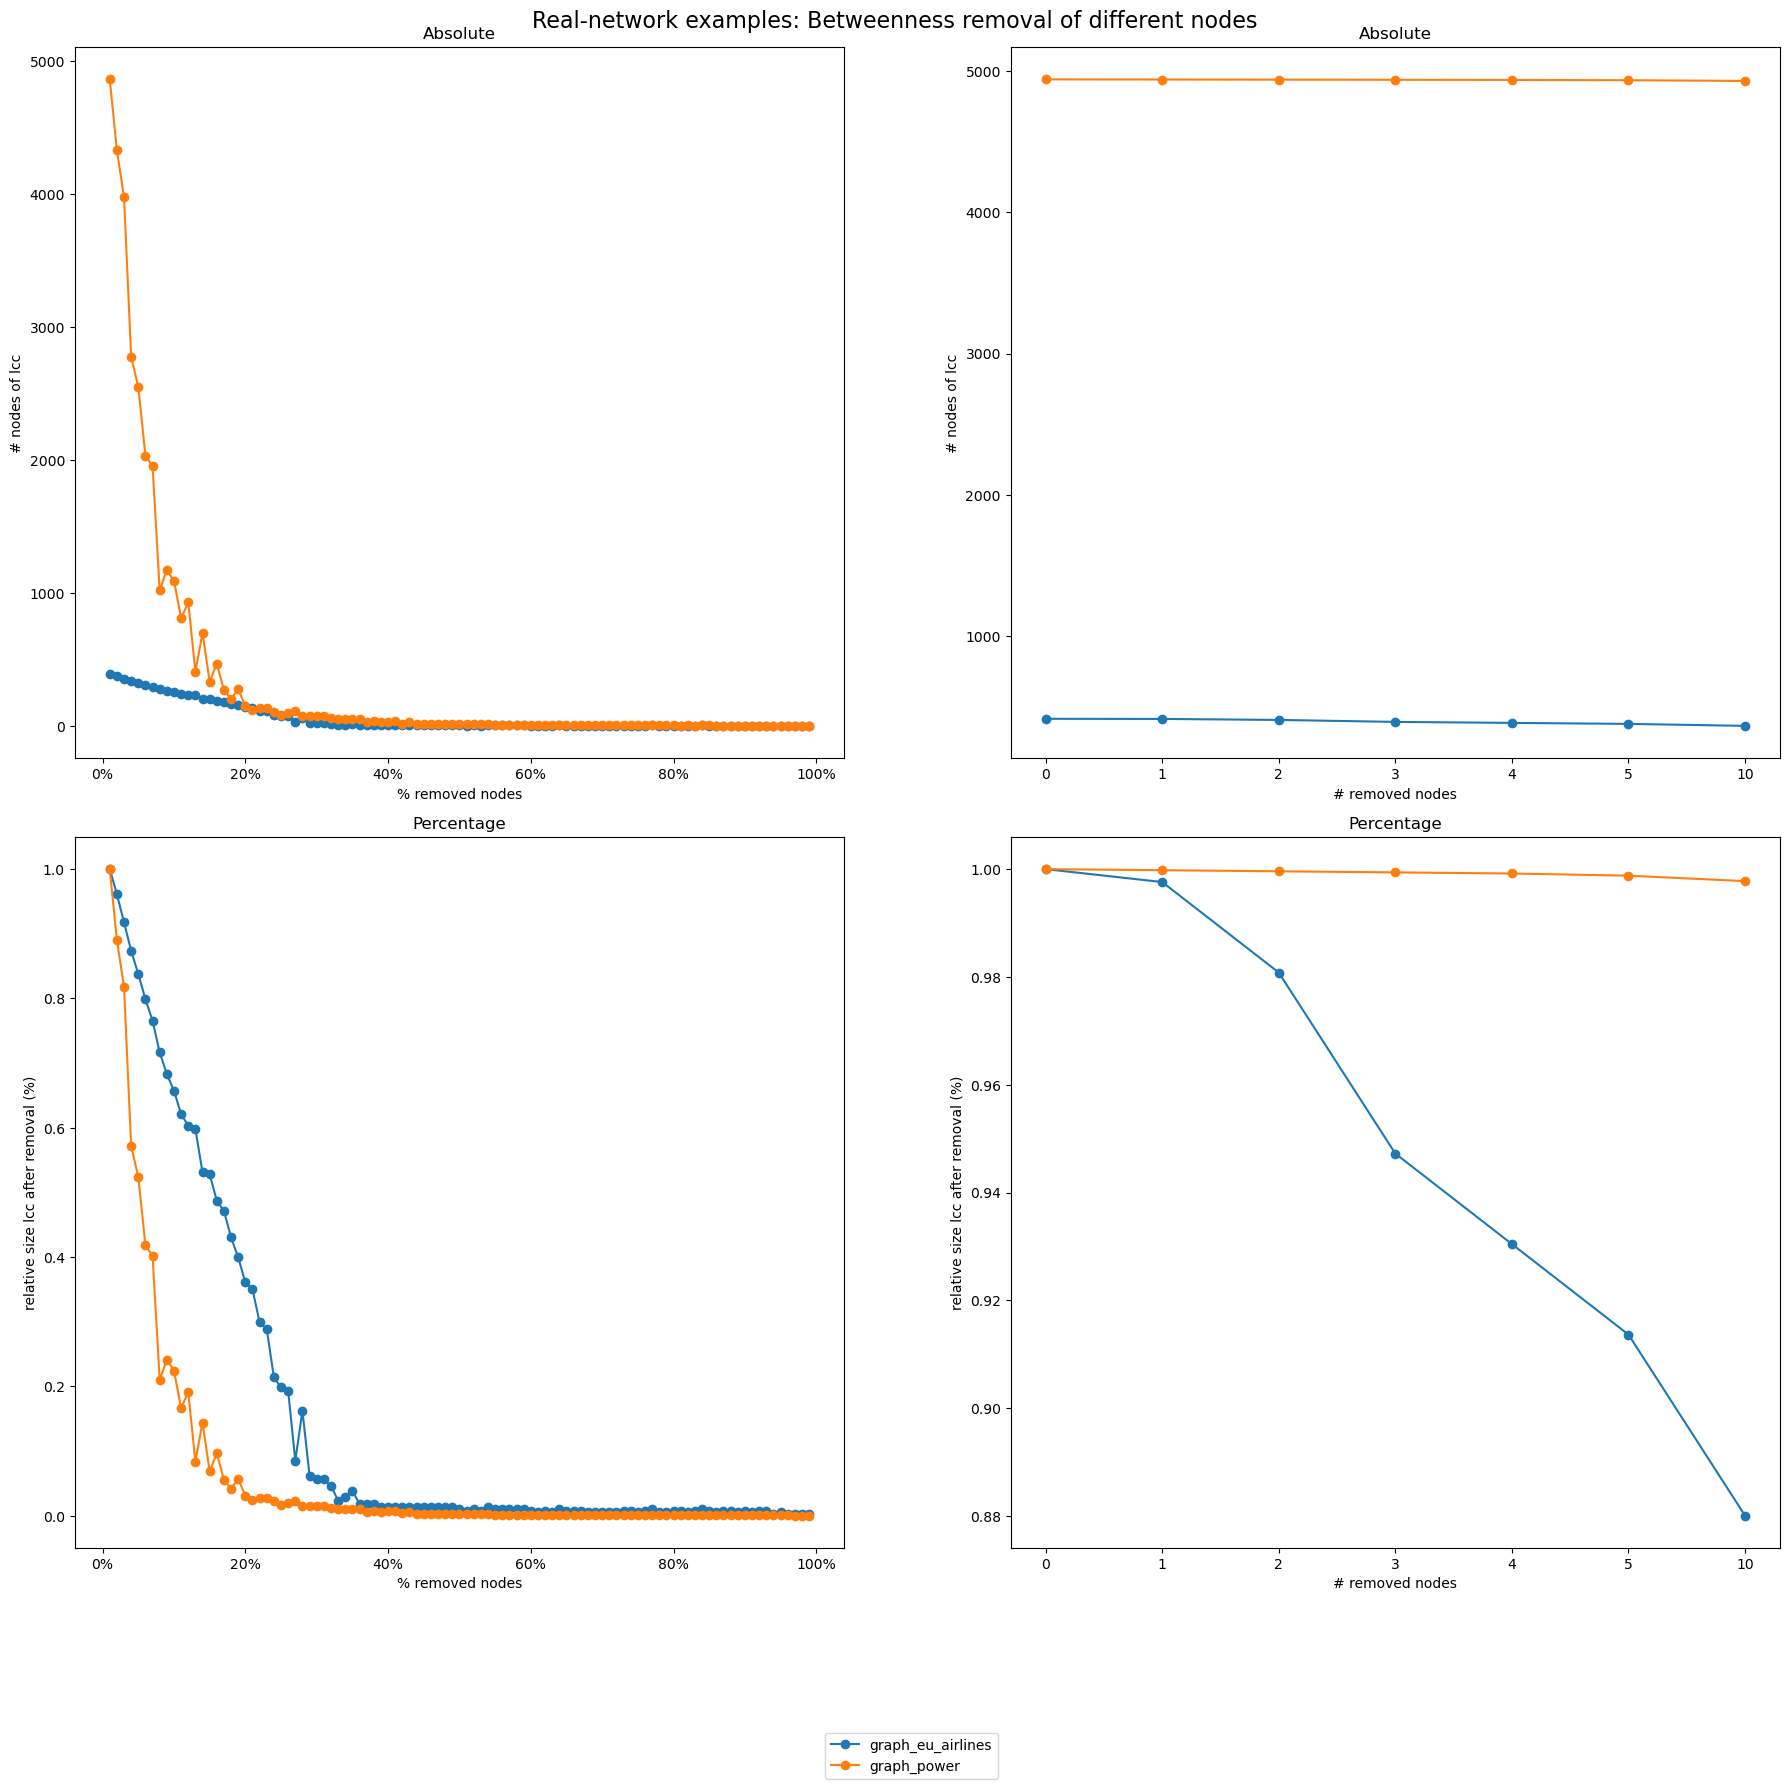

In [357]:
plot_removed_data(plot_data_betweenness, 'Real-network examples: Betweenness removal of different nodes')

In [358]:
plot_data_degree = generate_plot_data(target_degree_centrality_removed_graphs)

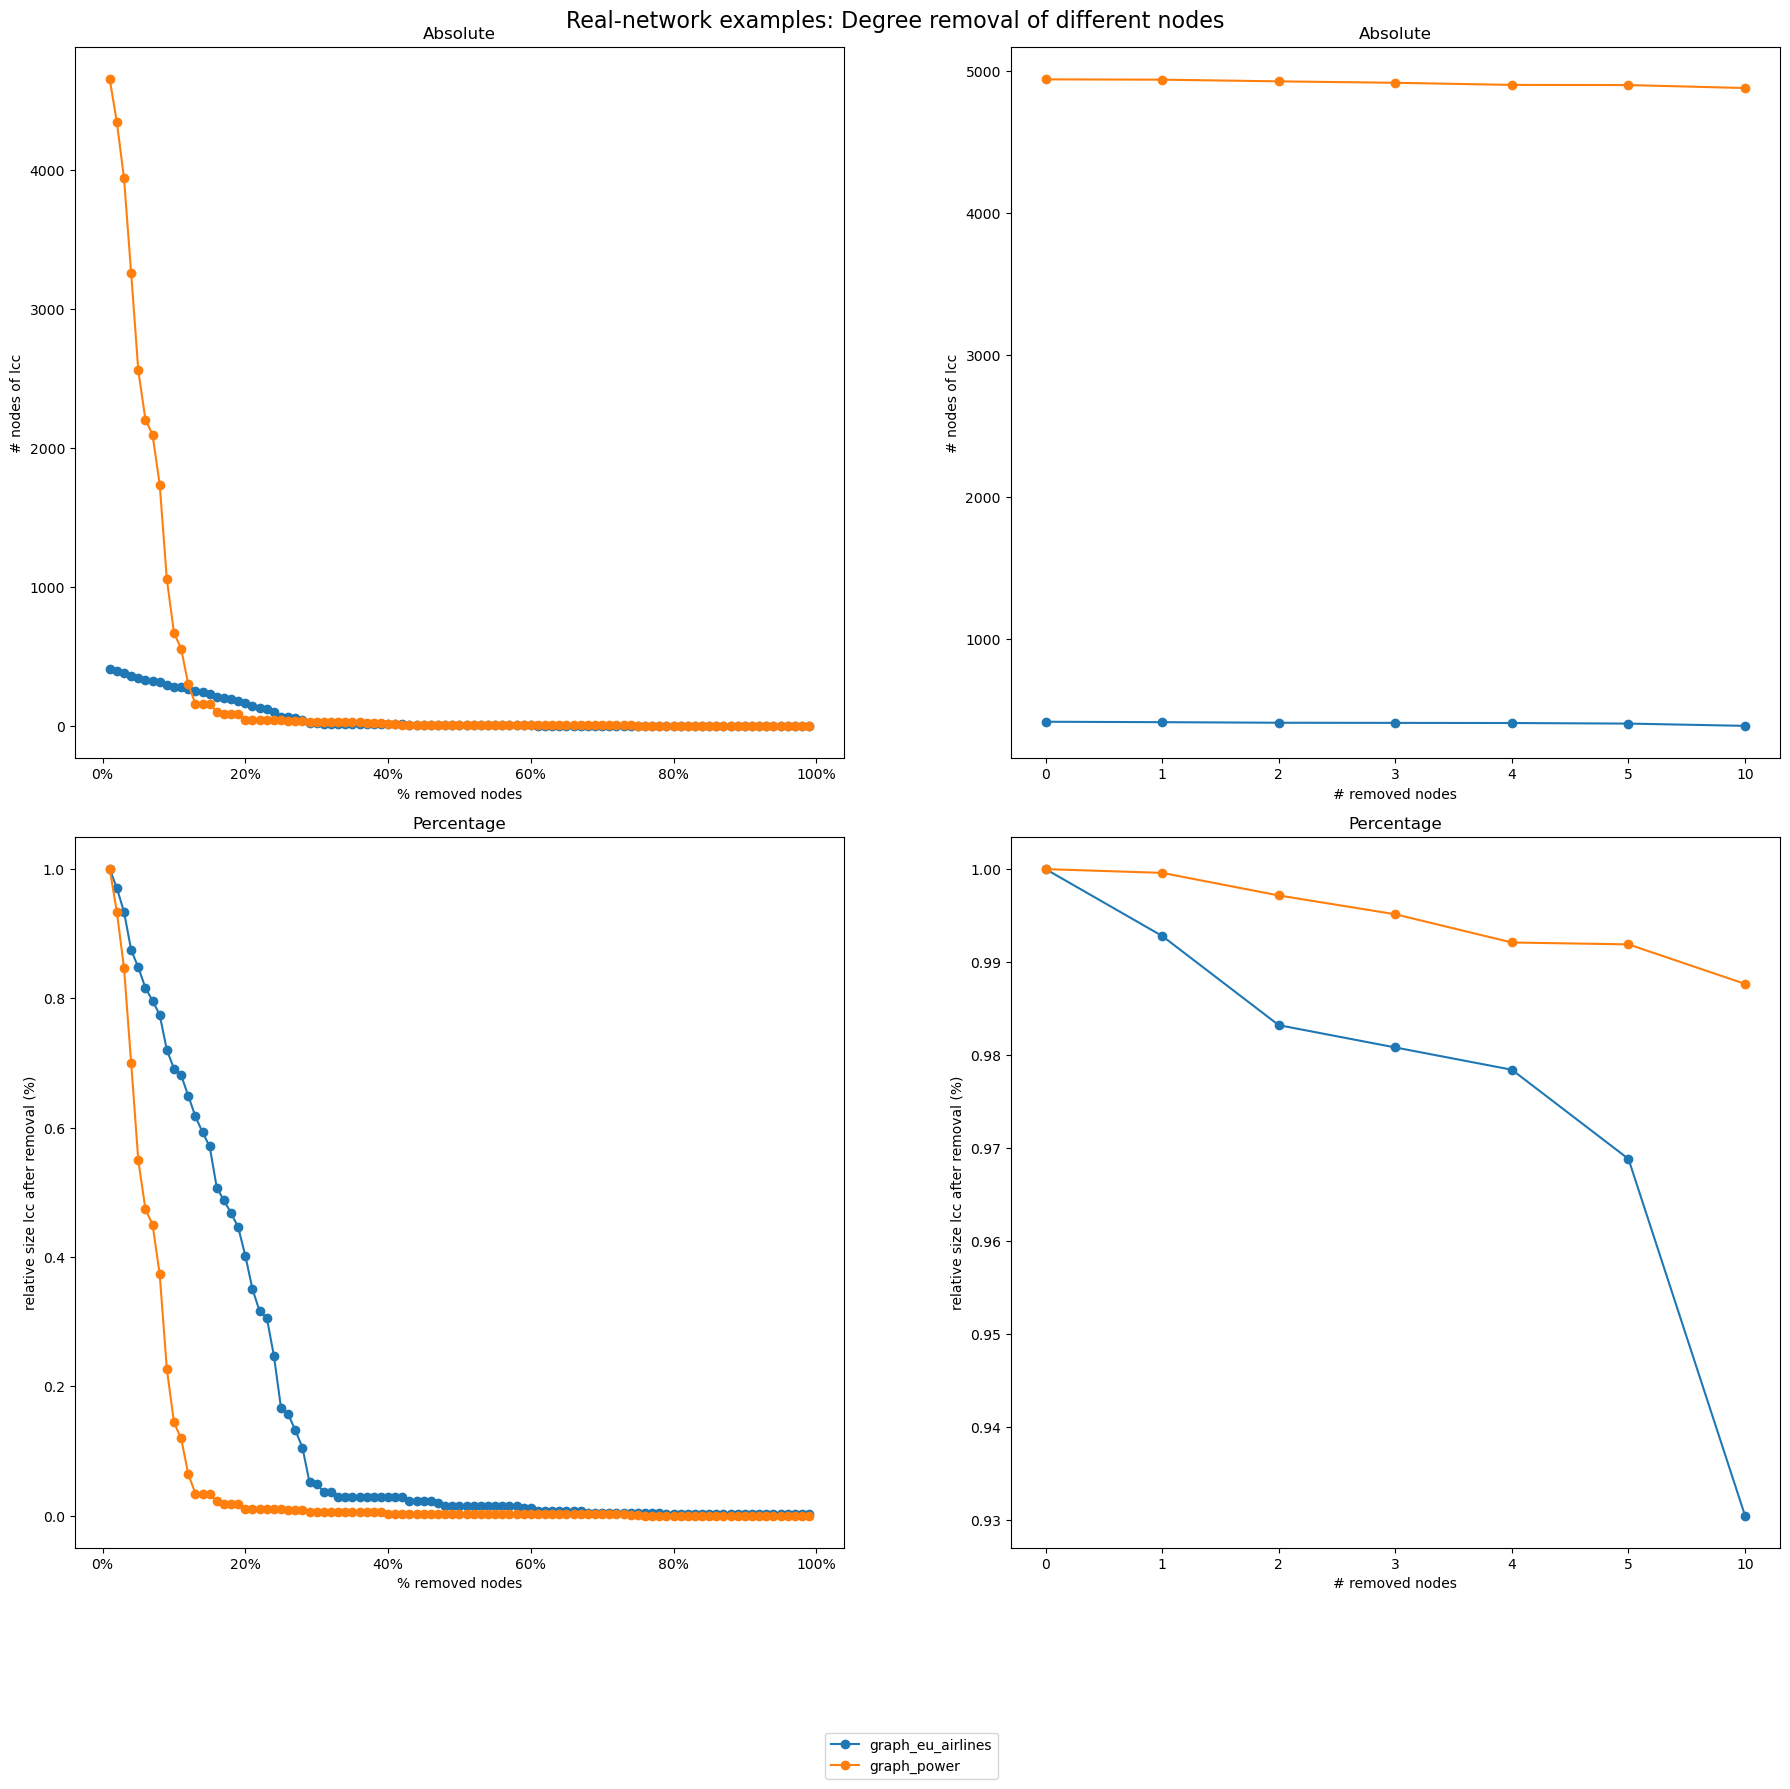

In [359]:
plot_removed_data(plot_data_degree, 'Real-network examples: Degree removal of different nodes')

In [360]:
ba_graphs

{2: {1: <networkx.classes.graph.Graph at 0x11fad7ed0>},
 4: {1: <networkx.classes.graph.Graph at 0x1201531d0>}}

In [361]:
er_graphs_samples = {f"{outer_key}k-{inner_key}": value for outer_key, inner_dict in er_graphs.items() for inner_key, value in inner_dict.items()}
print(er_graphs_samples)

{'1k-1': <networkx.classes.graph.Graph object at 0x11f733fd0>, '4k-1': <networkx.classes.graph.Graph object at 0x155c32210>}


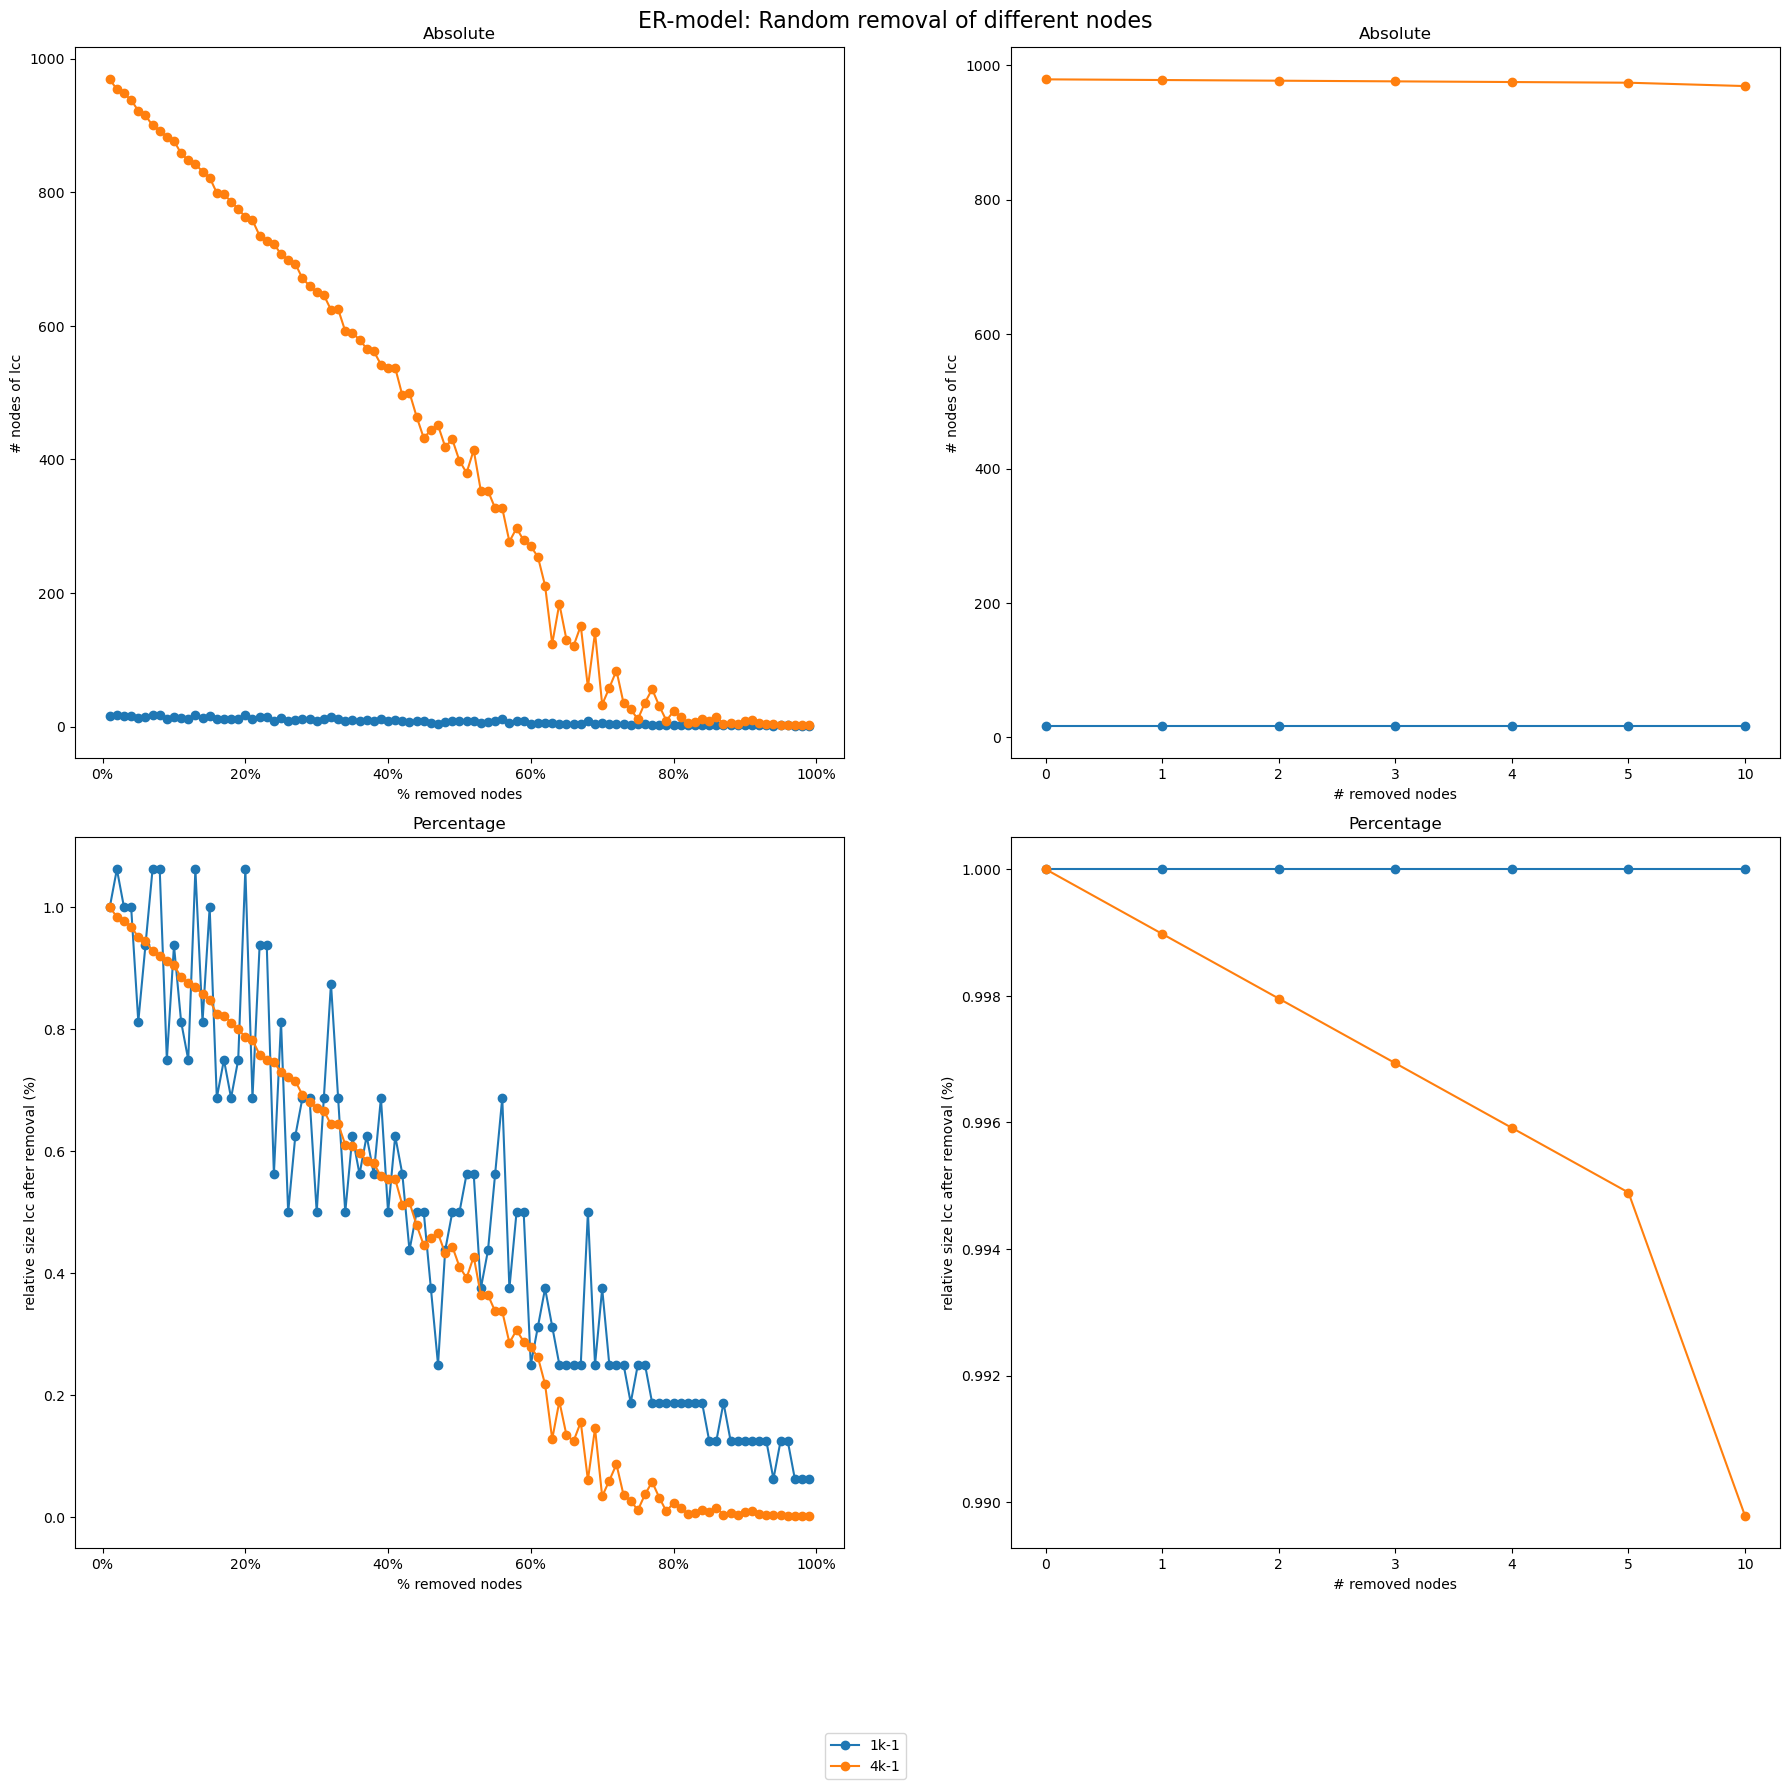

In [362]:
random_removed_er_graphs = generate_random_removed_graphs(graphs=er_graphs_samples, percentages_to_be_removed=PERCENTAGES_TO_BE_REMOVED, top_n_to_be_removed=TOP_N_TO_BE_REMOVED)
plot_er_data_random = generate_plot_data(random_removed_er_graphs)
plot_removed_data(plot_er_data_random, 'ER-model: Random removal of different nodes')

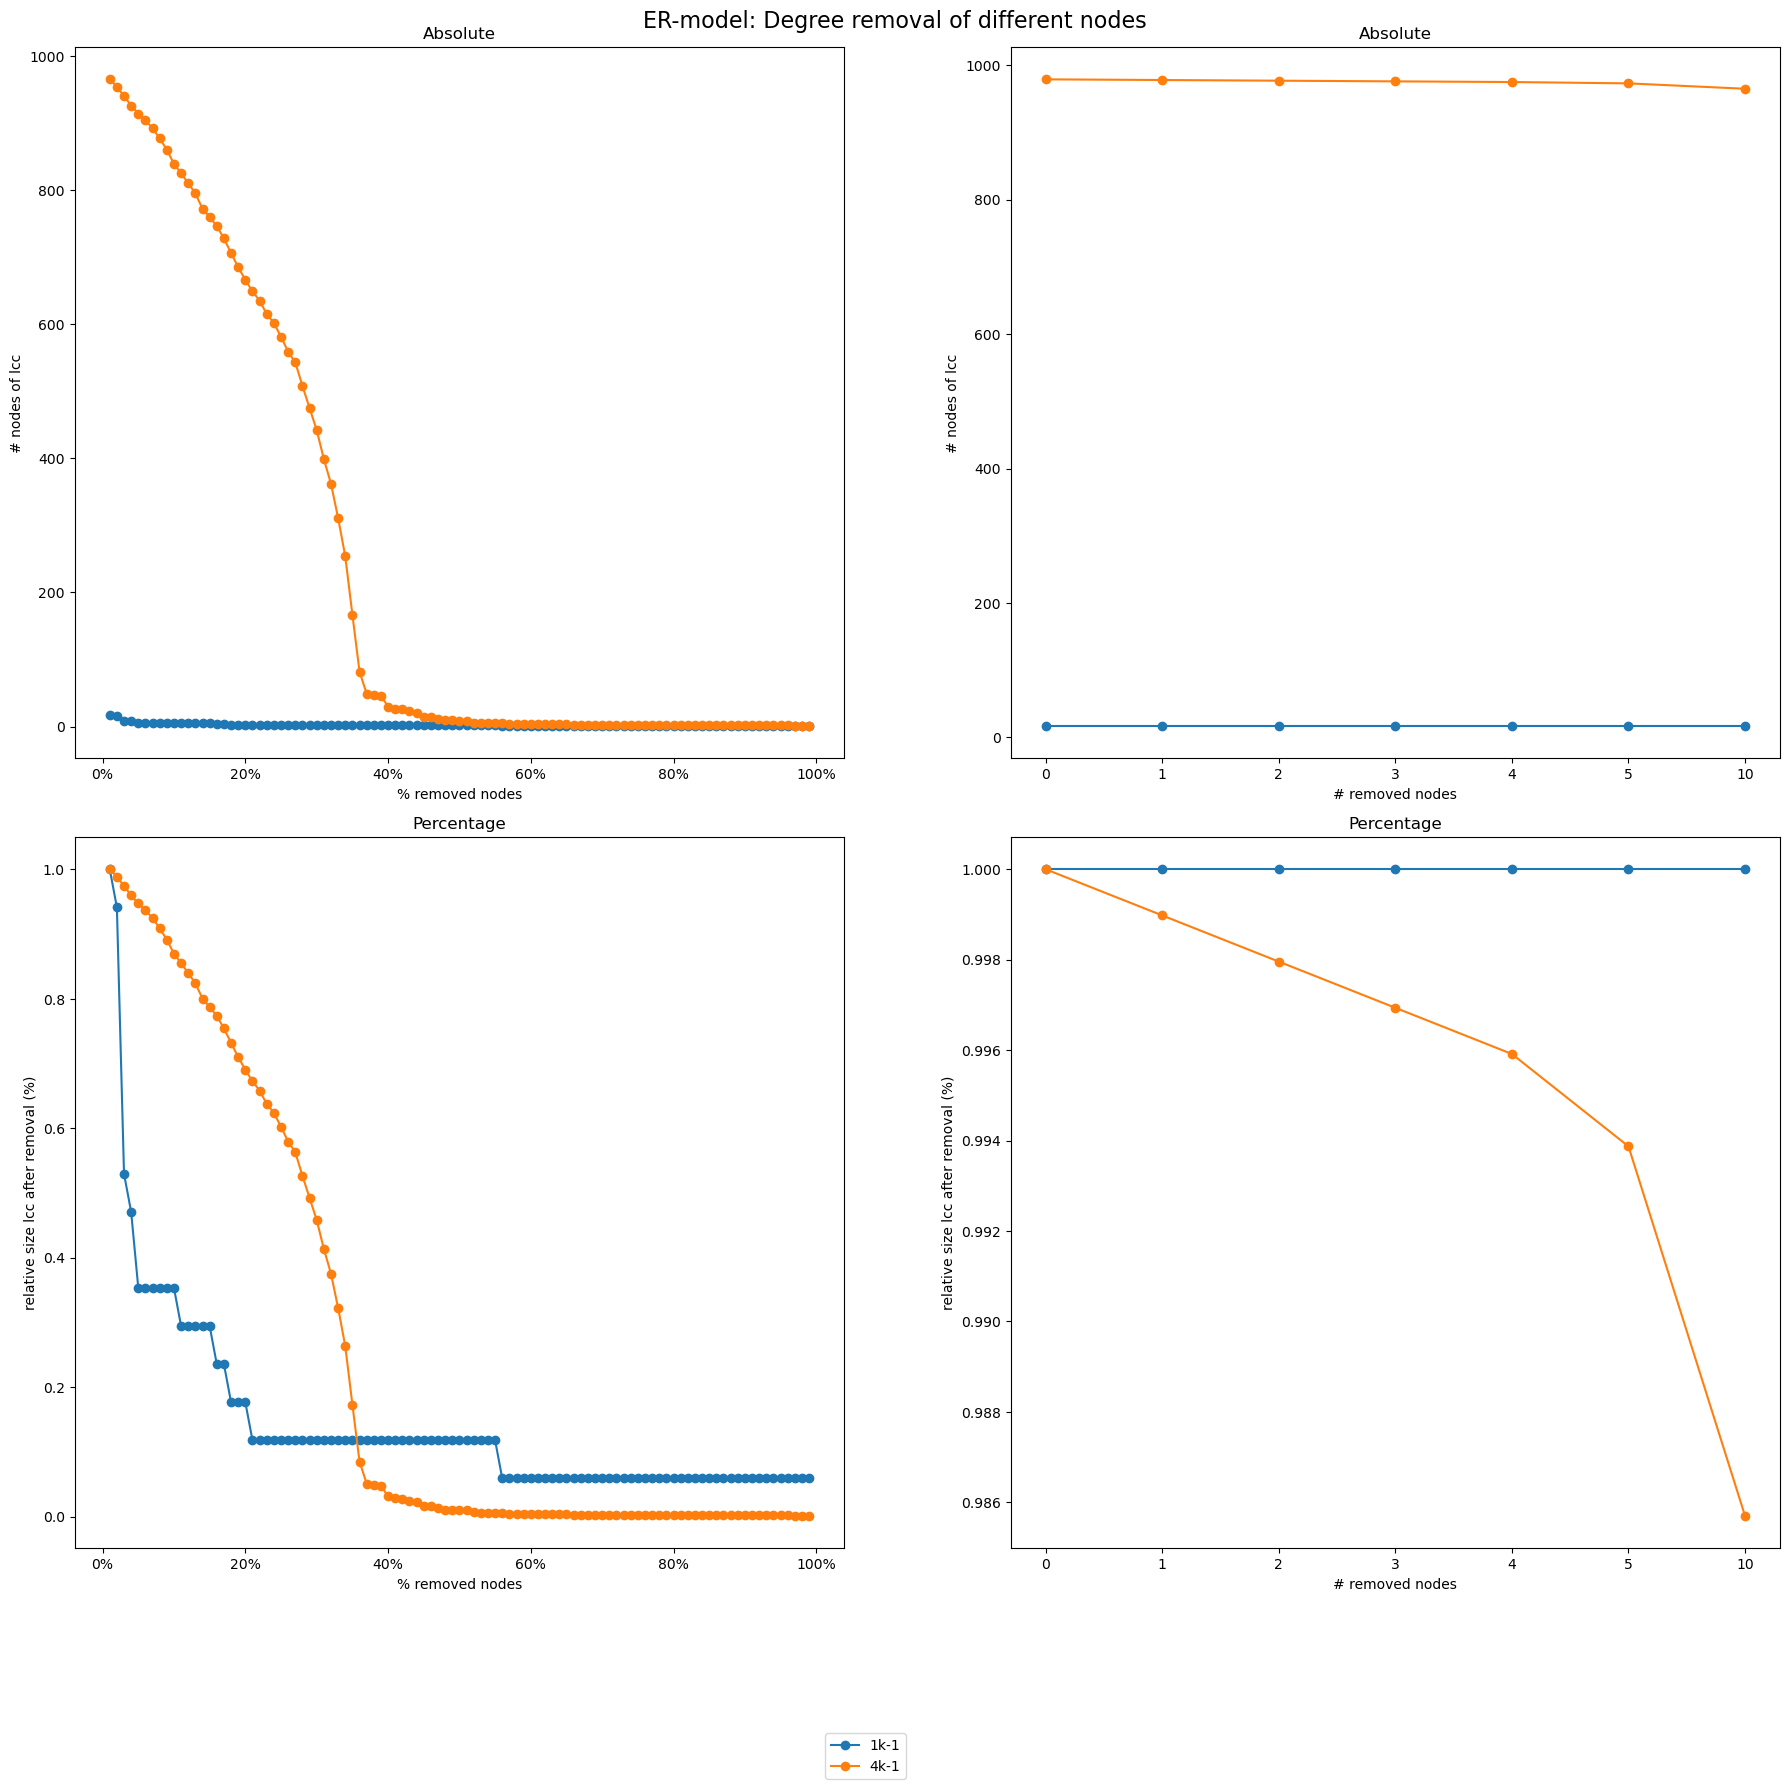

In [363]:
degree_removed_er_graphs = generate_target_degree_centrality_removed_graphs(graphs=er_graphs_samples, percentages_to_be_removed=PERCENTAGES_TO_BE_REMOVED, top_n_to_be_removed=TOP_N_TO_BE_REMOVED)
plot_er_data_degree = generate_plot_data(degree_removed_er_graphs)
plot_removed_data(plot_er_data_degree, 'ER-model: Degree removal of different nodes')

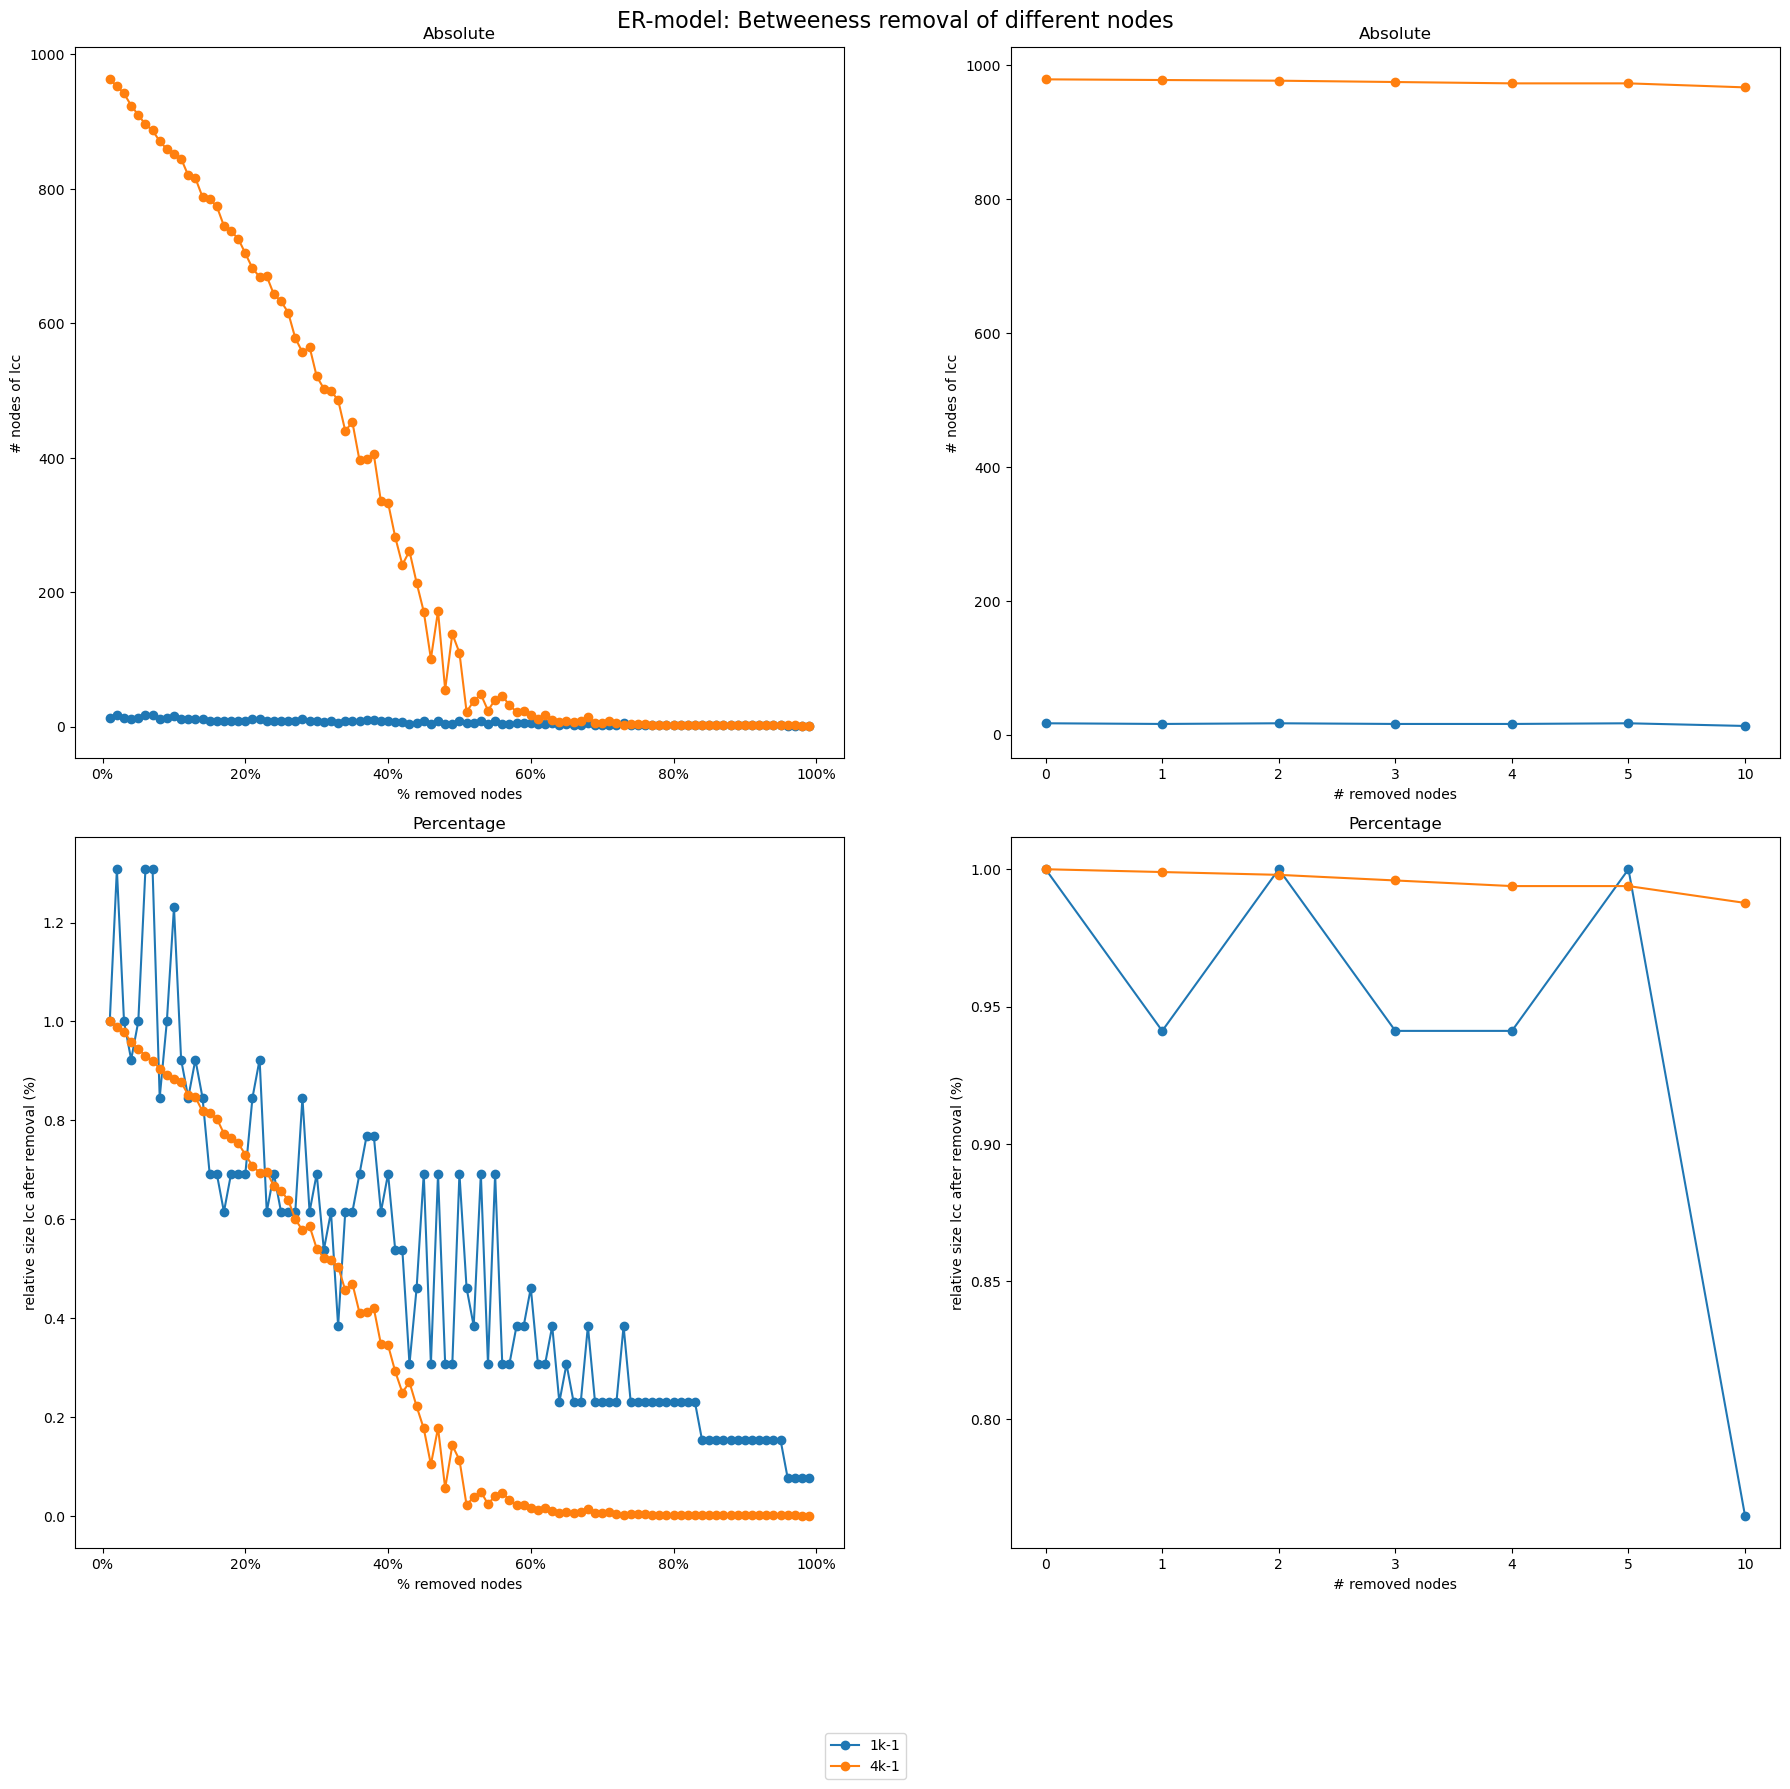

In [364]:
betweenness_removed_er_graphs = generate_target_betweenness_centrality_removed_graphs(graphs=er_graphs_samples, percentages_to_be_removed=PERCENTAGES_TO_BE_REMOVED, top_n_to_be_removed=TOP_N_TO_BE_REMOVED)
plot_er_data_betweenness = generate_plot_data(betweenness_removed_er_graphs)
plot_removed_data(plot_er_data_betweenness, 'ER-model: Betweeness removal of different nodes')

In [365]:
ba_graphs_samples = {f"{outer_key}m-{inner_key}": value for outer_key, inner_dict in ba_graphs.items() for inner_key, value in inner_dict.items()}
print(ba_graphs_samples)

{'2m-1': <networkx.classes.graph.Graph object at 0x11fad7ed0>, '4m-1': <networkx.classes.graph.Graph object at 0x1201531d0>}


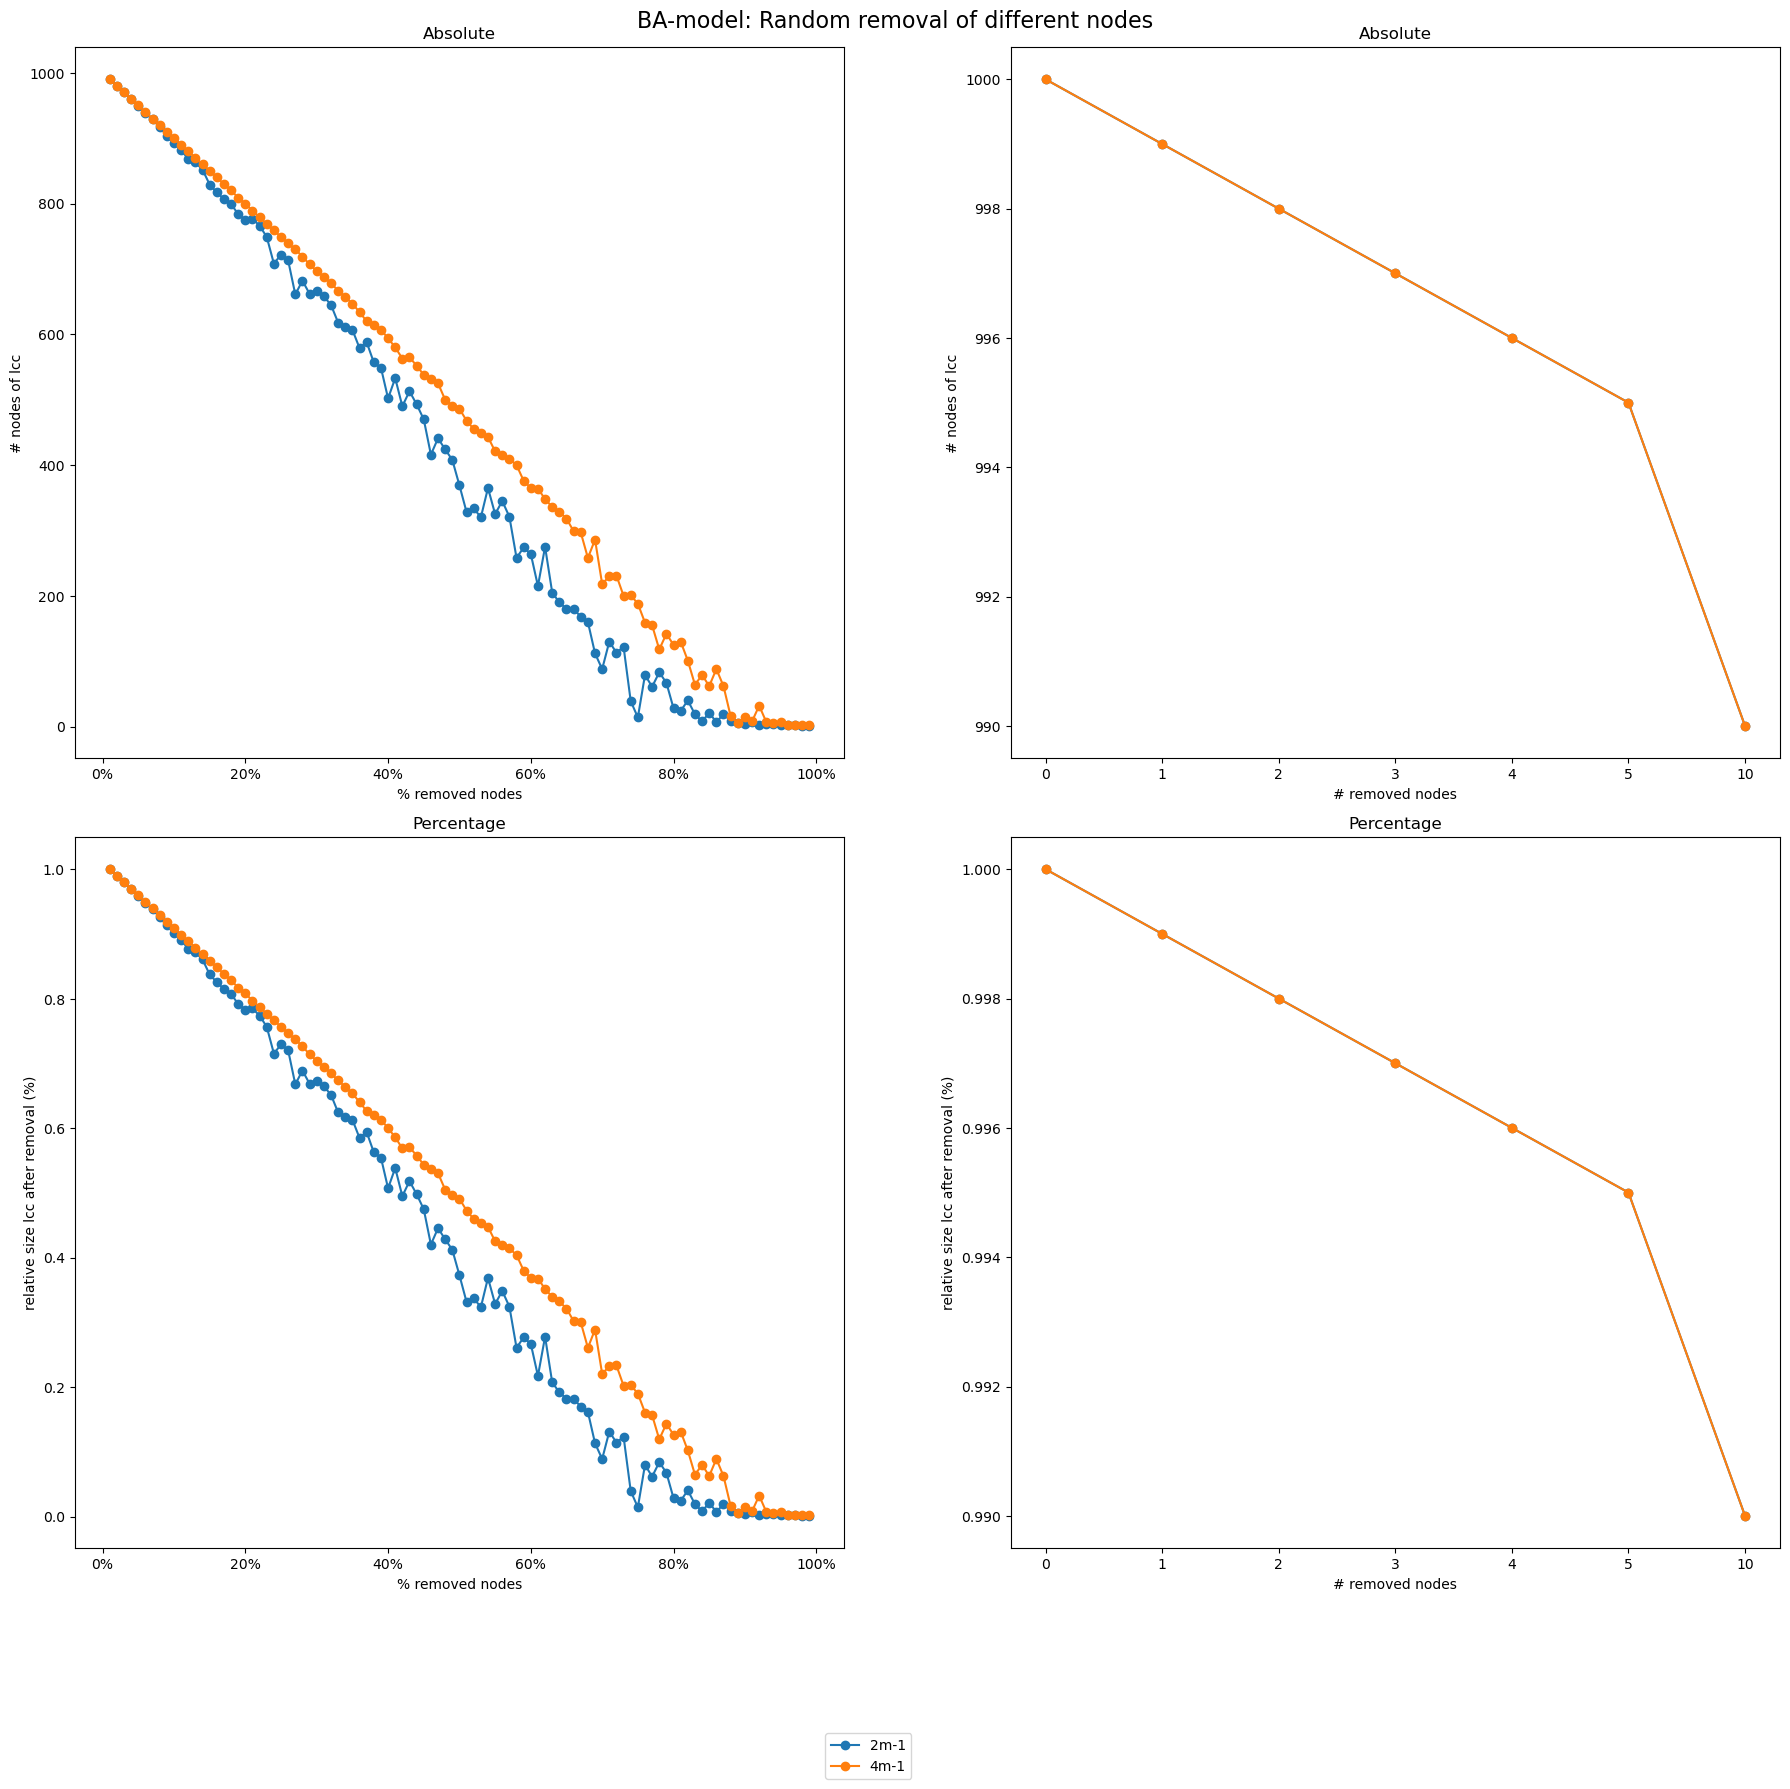

In [366]:
random_removed_ba_graphs = generate_random_removed_graphs(graphs=ba_graphs_samples, percentages_to_be_removed=PERCENTAGES_TO_BE_REMOVED, top_n_to_be_removed=TOP_N_TO_BE_REMOVED)
plot_ba_data_random = generate_plot_data(random_removed_ba_graphs)
plot_removed_data(plot_ba_data_random, 'BA-model: Random removal of different nodes')

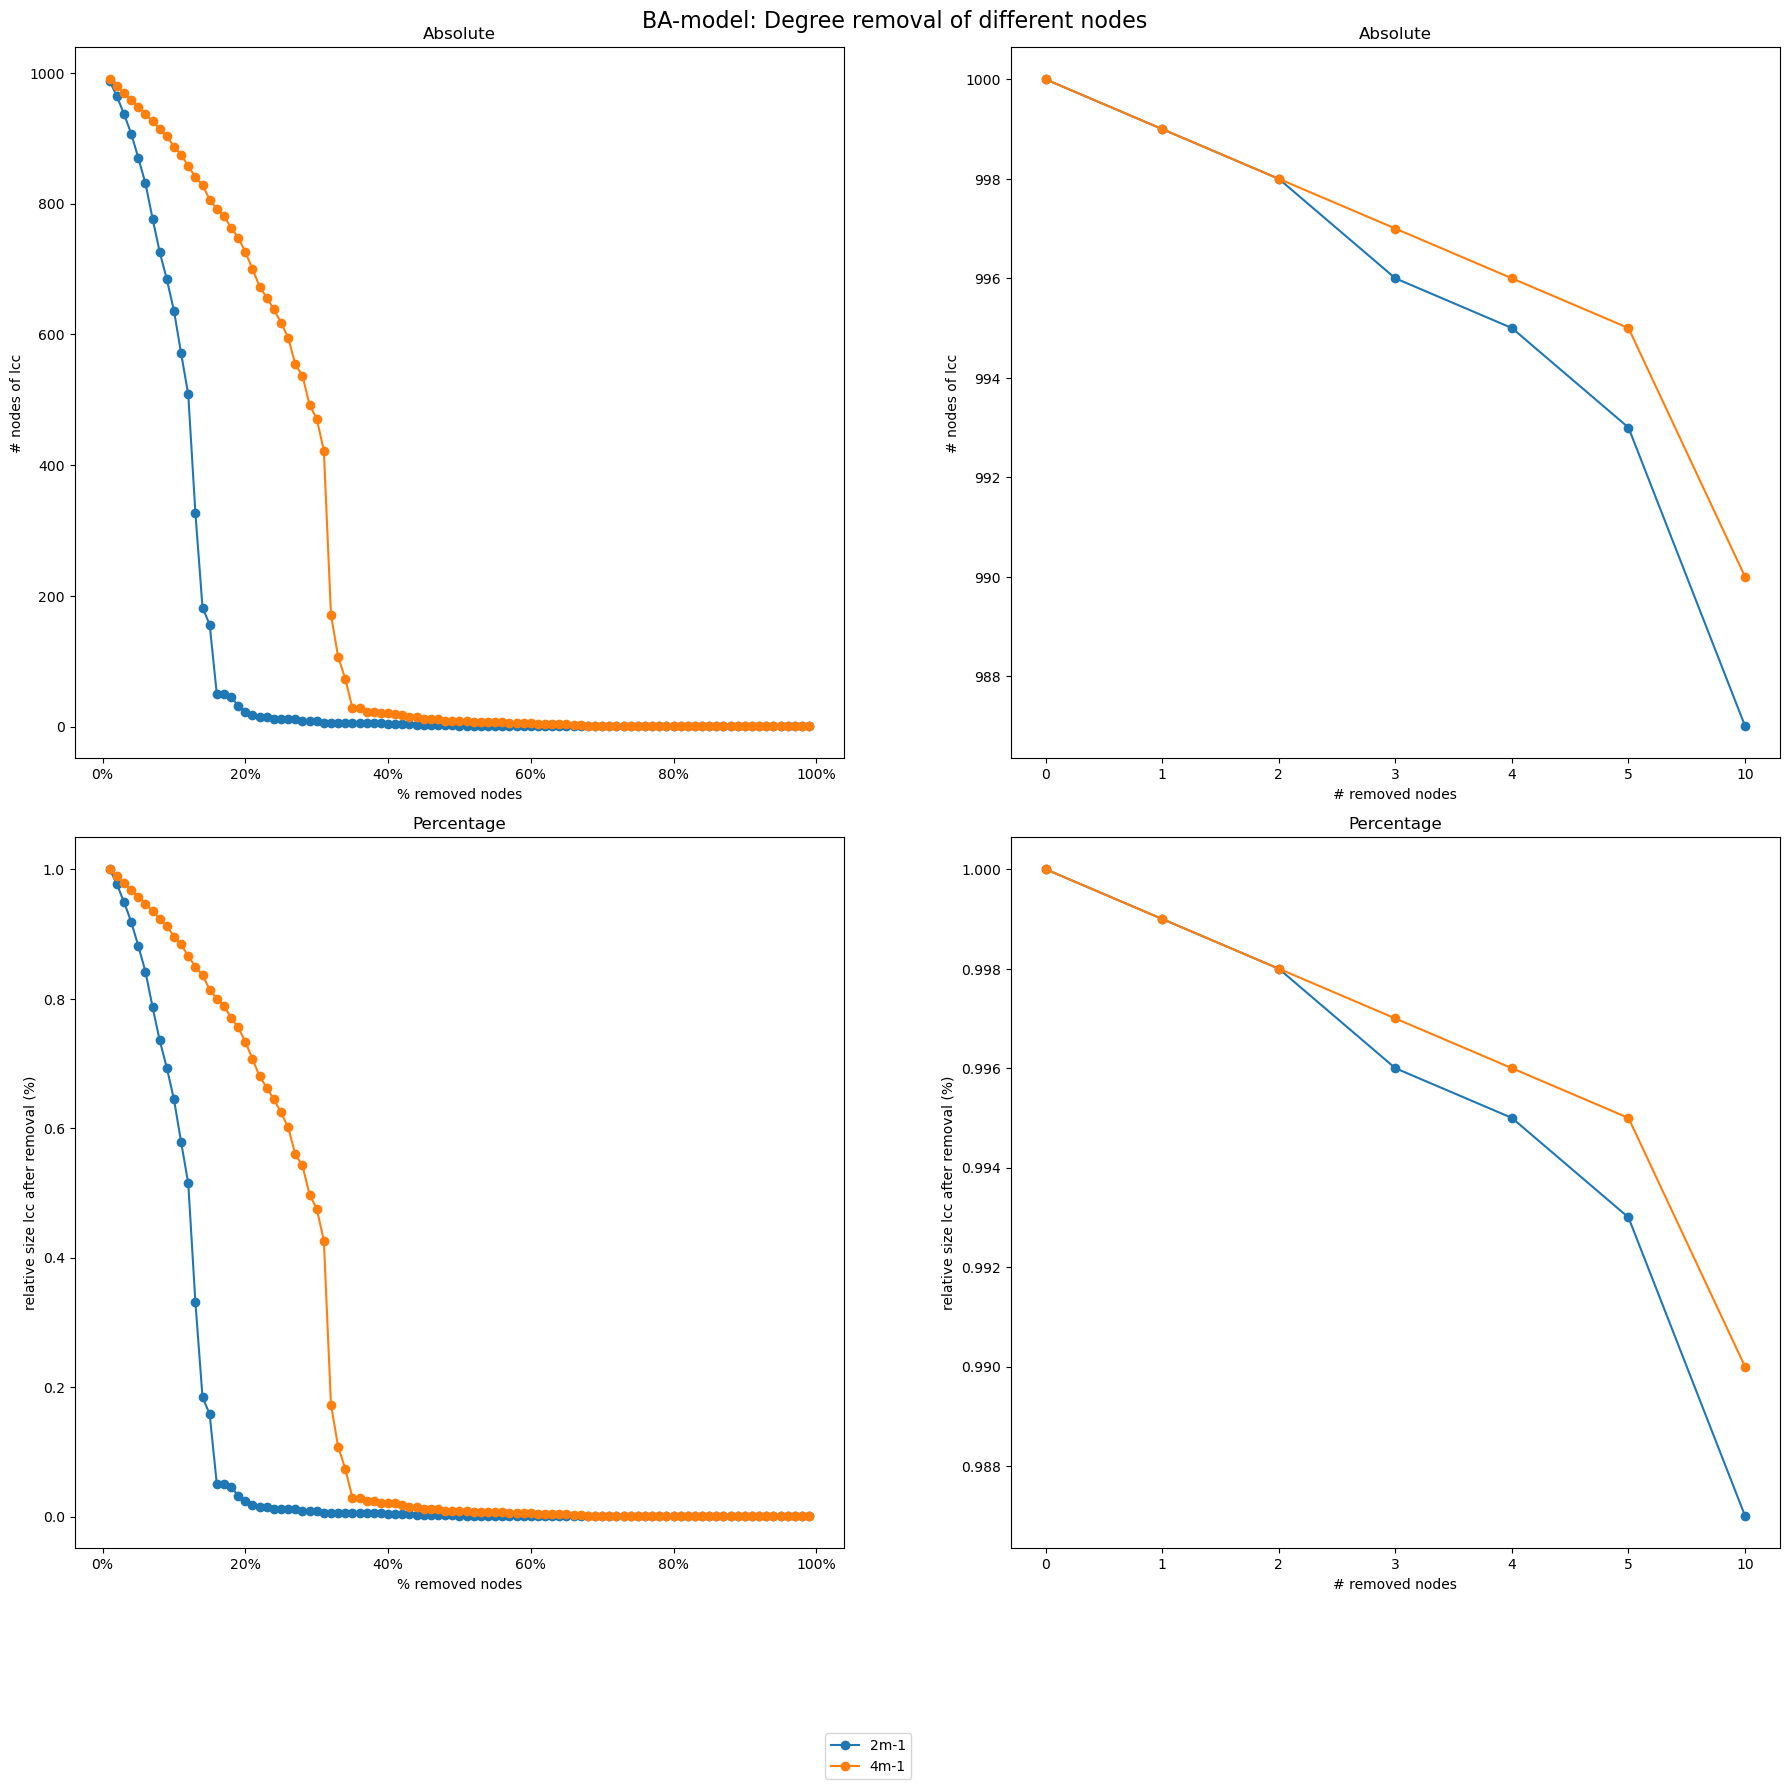

In [367]:
degree_removed_ba_graphs = generate_target_degree_centrality_removed_graphs(graphs=ba_graphs_samples, percentages_to_be_removed=PERCENTAGES_TO_BE_REMOVED, top_n_to_be_removed=TOP_N_TO_BE_REMOVED)
plot_ba_data_degree = generate_plot_data(degree_removed_ba_graphs)
plot_removed_data(plot_ba_data_degree, 'BA-model: Degree removal of different nodes')

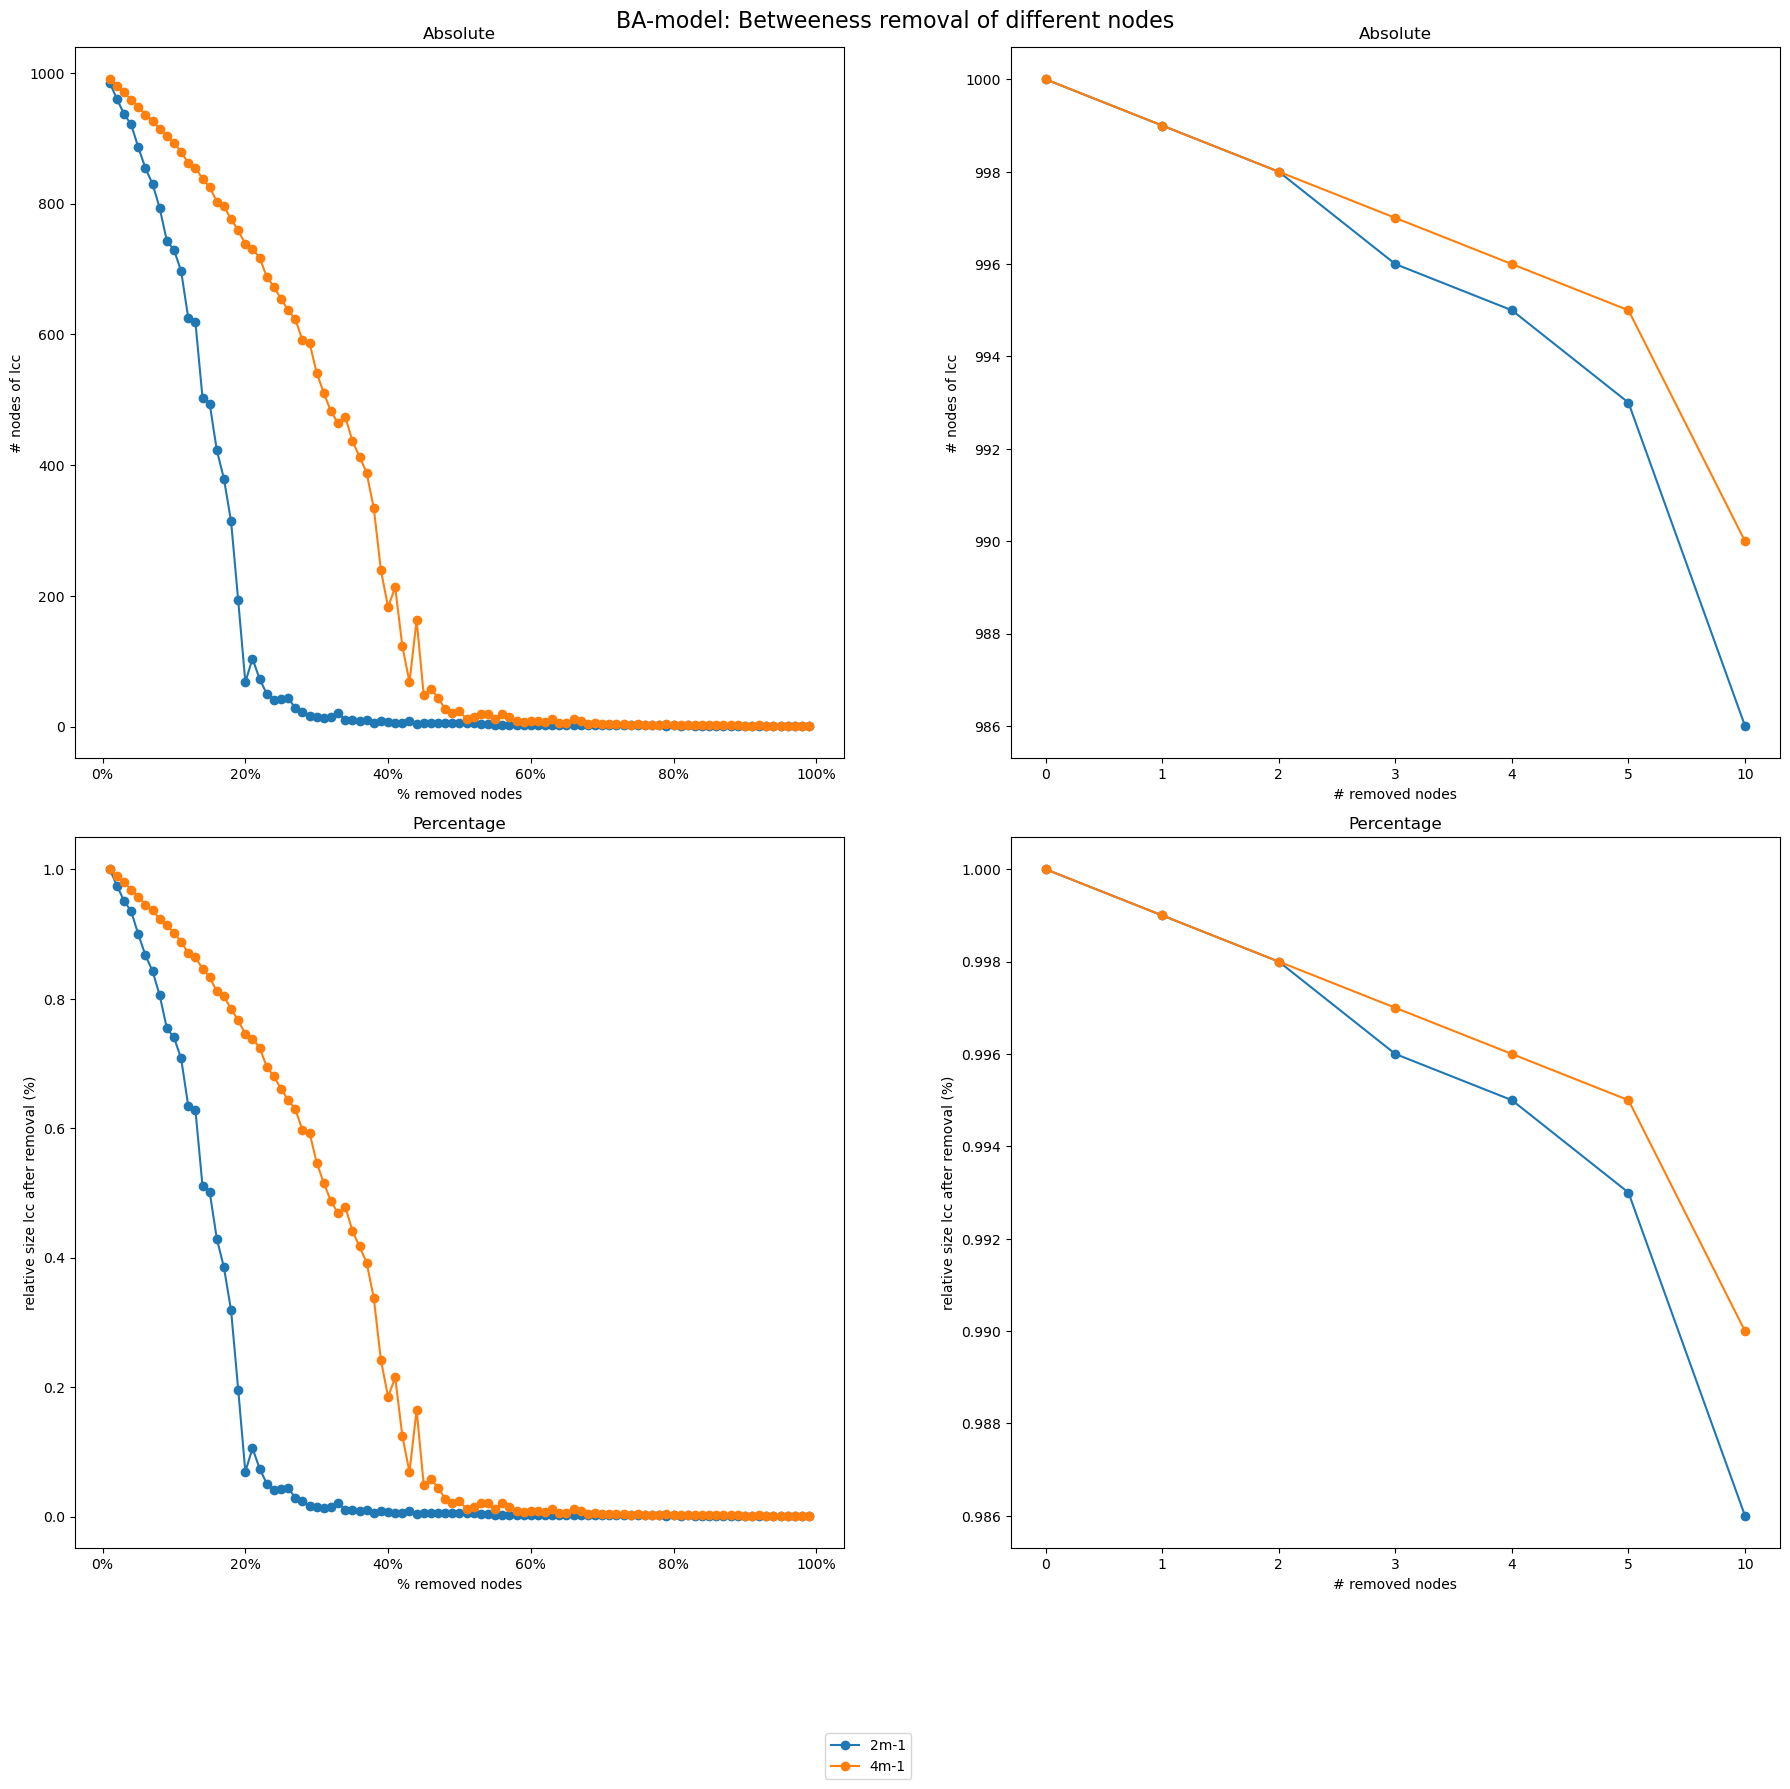

In [368]:
betweenness_removed_ba_graphs = generate_target_betweenness_centrality_removed_graphs(graphs=ba_graphs_samples, percentages_to_be_removed=PERCENTAGES_TO_BE_REMOVED, top_n_to_be_removed=TOP_N_TO_BE_REMOVED)
plot_ba_data_betweenness = generate_plot_data(betweenness_removed_ba_graphs)
plot_removed_data(plot_ba_data_betweenness, 'BA-model: Betweeness removal of different nodes')

In [369]:
#plot_data_random

In [370]:
#plot_data_degree

In [371]:
#plot_data_betweenness

In [372]:
eu_airlines_plot_data = {
    'random': plot_data_random['graph_eu_airlines'],
    'degree': plot_data_degree['graph_eu_airlines'],
    'betweenness': plot_data_betweenness['graph_eu_airlines']
}

In [373]:
#eu_airlines_plot_data

In [374]:
power_plot_data = {
    'random': plot_data_random['graph_power'],
    'degree': plot_data_degree['graph_power'],
    'betweenness': plot_data_betweenness['graph_power']
}

In [375]:
#power_plot_data

In [376]:
#plot_er_data_random

In [377]:
er_plot_data = {
    '1k-1': {
        'random': plot_er_data_random['1k-1'],
        'degree': plot_er_data_degree['1k-1'],
        'betweenness': plot_er_data_betweenness['1k-1']
    },
    '4k-1': {
        'random': plot_er_data_random['4k-1'],
        'degree': plot_er_data_degree['4k-1'],
        'betweenness': plot_er_data_betweenness['4k-1']
    }
}

In [378]:
#er_plot_data

In [379]:
#plot_ba_data_random

In [380]:
ba_plot_data = {
    '2m-1': {
        'random': plot_ba_data_random['2m-1'],
        'degree': plot_ba_data_degree['2m-1'],
        'betweenness': plot_ba_data_betweenness['2m-1']
    },
    '4m-1': {
        'random': plot_ba_data_random['4m-1'],
        'degree': plot_ba_data_degree['4m-1'],
        'betweenness': plot_ba_data_betweenness['4m-1']
    }
}

In [381]:
def plot_attacks(data_dict):
    plt.figure(figsize=(10, 6))

    for key, value in data_dict.items():
        for inner_key, inner_value in value.items():
            x_data = inner_value['percentage']['x_percentages_removed']
            y_data = inner_value['percentage']['y_size_lcc_frac']
            plt.plot(x_data, y_data, label=f'{key}_{inner_key}')

    plt.xlabel('x_percentages_removed')
    plt.ylabel('y_size_lcc_frac')
    plt.title('Percentage Removed vs Fraction of Largest Connected Component')
    plt.legend()
    plt.grid(True)
    plt.show()

In [382]:
plot_data_real_networks = {
    'eu_airlines': eu_airlines_plot_data,
    'power': power_plot_data
}

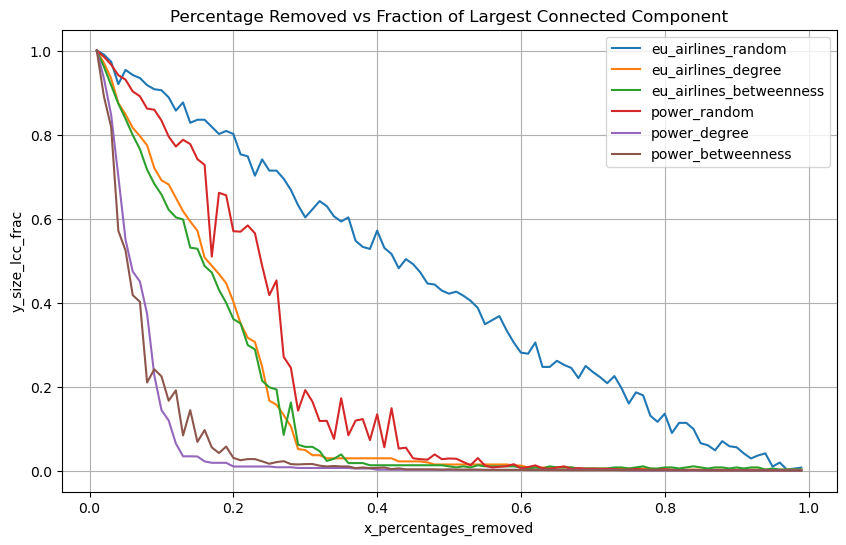

In [383]:
plot_attacks(plot_data_real_networks)

In [384]:
def plot_attacks(plot_data, plot_name):
    plt.figure(figsize=(10, 6))
    for inner_key, inner_value in plot_data.items():
        x_data = inner_value['percentage']['x_percentages_removed']
        y_data = inner_value['percentage']['y_size_lcc_frac']
        plt.plot(x_data, y_data, label=f'{inner_key} attack', alpha=0.8)
        

    plt.xlabel('Nodes removed in percentage ')
    plt.ylabel(fr'Relative size of the reduced LCC: $\frac{{LCC}}{{LCC\_orig}}$')
    plt.title(f'{plot_name}: Fraction of Largest Connected Component vs. removed nodes ')
    plt.legend()
    plt.grid(True)
    plot_name_formatted=plot_name.replace('$', '')
    plot_name_formatted=plot_name_formatted.replace(' ', '_')
    plot_name_formatted=plot_name_formatted.lower()
    file_name=f"{plot_name_formatted}-attacks.png"
    complete_plot_filename=os.path.join(OUTPUT_PATH_NODE_REMOVALS, file_name)
    plt.savefig(complete_plot_filename)
    plt.show()

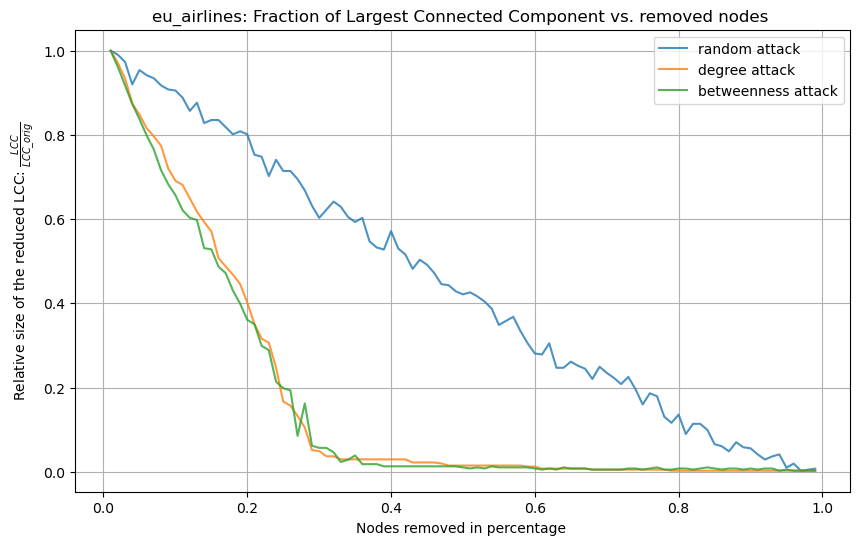

In [385]:
plot_attacks(plot_data_real_networks['eu_airlines'], 'eu_airlines')

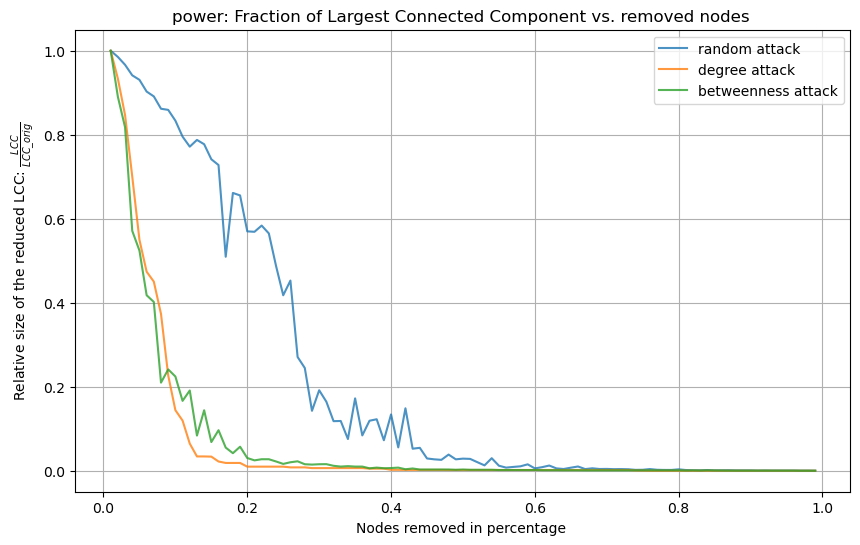

In [386]:
plot_attacks(plot_data_real_networks['power'], 'power')

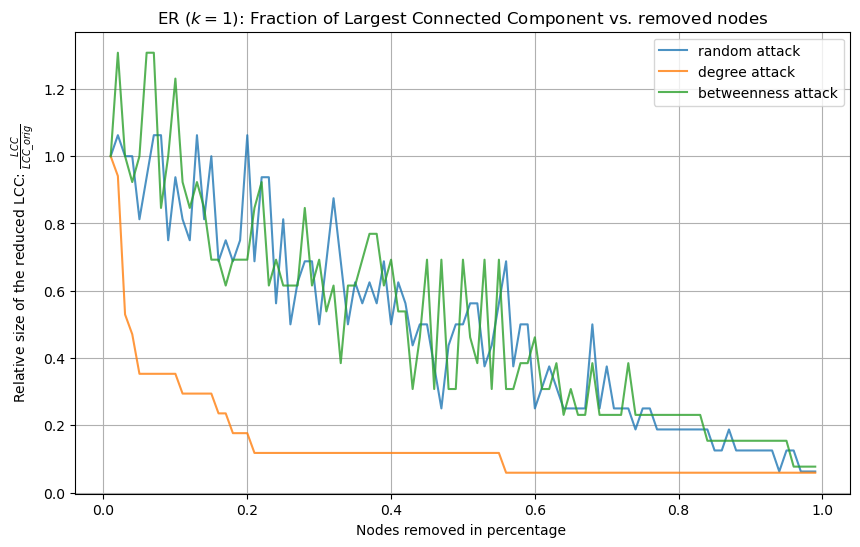

In [387]:
plot_attacks(er_plot_data['1k-1'], fr'ER ($k=1$)')

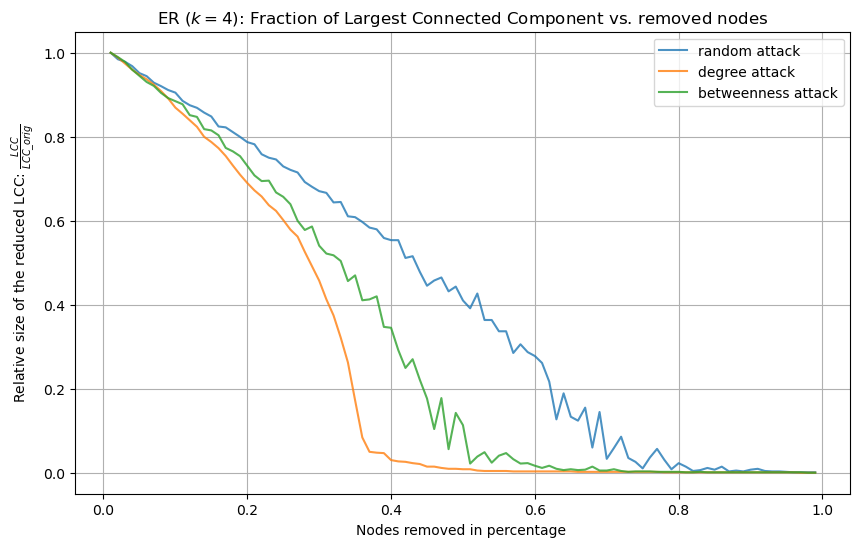

In [388]:
plot_attacks(er_plot_data['4k-1'], fr'ER ($k=4$)')

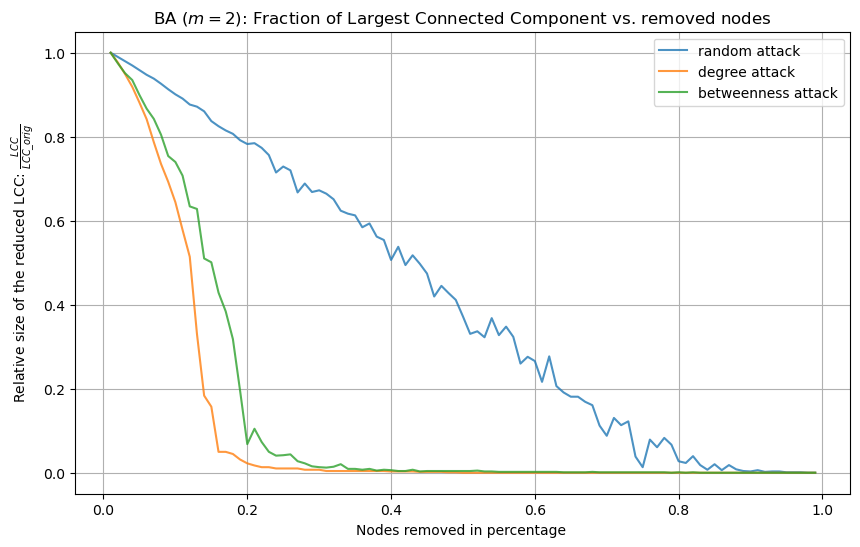

In [389]:
plot_attacks(ba_plot_data['2m-1'], fr'BA ($m=2$)')

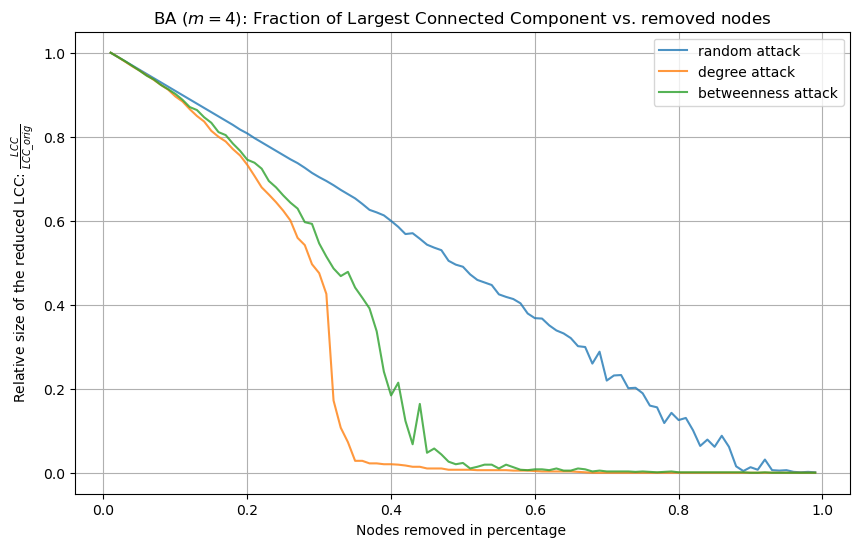

In [390]:
plot_attacks(ba_plot_data['4m-1'], fr'BA ($m=4$)')

## 4. Comment the plots, using what we discussed in class.

Creating Results:
`jupyter nbconvert Assignment_03.ipynb --to pdf --output Assignment_03_Results-T3.pdf

In [391]:
import os
os.system('jupyter nbconvert Assignment_03.ipynb --to pdf --output Assignment_03_Results-T3.pdf')

[NbConvertApp] Converting notebook Assignment_03.ipynb to pdf
[NbConvertApp] Support files will be in Assignment_03_Results-T3_files/
[NbConvertApp] Making directory ./Assignment_03_Results-T3_files
[NbConvertApp] Writing 122706 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | bibtex had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 175299 bytes to Assignment_03_Results-T3.pdf


0